# Filling factor information patterns

This notebook determines the optical information patterns associated with small center-of-mass displacements of a spherical nanoparticle using incident fields defined through the objective filling factor.

## General imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm
from pathlib import Path

## Repository imports and default configuration

In [ ]:
from info_patterns.parameters import (SPHERE_GEOMETRY_PARAMS, DEFAULT_MATERIAL_NAME, DEFAULT_MATERIAL_KWARGS, DEFAULT_WAVELENGTH_NM, FAST_FARFIELD_PARAMS, 
                                      DEFAULT_DYADS_PARAMS, DEFAULT_COM_DISPLACEMENT_NM, DEFAULT_USETEX, DEFAULT_FONT_FAMILY, DEFAULT_FIGSIZE, DEFAULT_SAVE_TYPE, DEFAULT_2D_PLANES, 
                                      DEFAULT_2D_NORMALIZE, DEFAULT_2D_FILL, DEFAULT_VECTOR_BEAM_NA, DEFAULT_VECTOR_BEAM_F_MM, DEFAULT_FILLING_FACTOR, DEFAULT_HERMITE_GAUSS00_FIELD_PARAMS, 
                                      DEFAULT_RADIAL_DOUGHNUT_FIELD_PARAMS, DEFAULT_OPTICAL_POWER_W, DEFAULT_FREE_SPACE_IMPEDANCE_OHM)
from info_patterns.generate_nanoparticle import (nanoparticle_geometry, nanoparticle_material)
from info_patterns.light_matter_interaction_simulation import (w0_from_filling_factor, hermite_gauss00_power_amplitude_factor, incident_field, field_propagation, com_scattered_farfield)
from info_patterns.information_patterns_simulation import (info_patterns_from_scattered_field)
from info_patterns.plots import (set_plot_style, plot3d_info_patterns, plot2d_info_patterns)

set_plot_style(usetex=DEFAULT_USETEX, font_family=DEFAULT_FONT_FAMILY, figsize=DEFAULT_FIGSIZE)
results_dir = "com_sphere_results"

## Nanoparticle geometry and material

In [3]:
geometry = nanoparticle_geometry(**SPHERE_GEOMETRY_PARAMS)
material = nanoparticle_material(DEFAULT_MATERIAL_NAME, **DEFAULT_MATERIAL_KWARGS)

## Optical setup and electromagnetic propagator

In [4]:
wavelength_nm = DEFAULT_WAVELENGTH_NM
farfield_params = FAST_FARFIELD_PARAMS

Ntheta = farfield_params["Nteta"]
Nphi = farfield_params["Nphi"]
field_index = farfield_params["field_index"]
r = farfield_params["r"]

disp_nm = DEFAULT_COM_DISPLACEMENT_NM

NA = DEFAULT_VECTOR_BEAM_NA
f_mm = DEFAULT_VECTOR_BEAM_F_MM
gamma = DEFAULT_FILLING_FACTOR

optical_power_W = DEFAULT_OPTICAL_POWER_W
impedance_ohm = DEFAULT_FREE_SPACE_IMPEDANCE_OHM

print("Global optical parameters")
print("wavelength =", wavelength_nm, "nm")
print("NA =", NA)
print("f =", f_mm, "mm")
print("gamma =", gamma)
print("optical power =", optical_power_W, "W")
print("impedance =", impedance_ohm, "Ohm")

dyads = field_propagation(**DEFAULT_DYADS_PARAMS)

Global optical parameters
wavelength = 1550.0 nm
NA = 0.8
f = 3.0 mm
gamma = 1.0
optical power = 0.001 W
impedance = 377.0 Ohm


## Hermite-Gauss incident field

In this cell, we build the `HermiteGauss00` incident field using the filling factor.

The function `w0_from_filling_factor` converts the filling factor into the beam waist `w0`. The function `hermite_gauss00_power_amplitude_factor` sets the field amplitude from the optical power and free-space impedance.

The resulting object `hermite_efield` is then passed to pyGDM as the incident optical field.

In [ ]:
hermite_params = DEFAULT_HERMITE_GAUSS00_FIELD_PARAMS.copy()
hermite_params["w0"] = w0_from_filling_factor(gamma=gamma, NA=hermite_params["NA"], f_mm=hermite_params["f"])
hermite_amplitude = hermite_gauss00_power_amplitude_factor(optical_power_W=optical_power_W, w0_mm=hermite_params["w0"], impedance_ohm=impedance_ohm)

# HermiteGauss00 requires exactly one of theta or polarization_state.
# Since we want to include the physical amplitude, use polarization_state
# and explicitly disable theta.
hermite_params["theta"] = None
hermite_params["polarization_state"] = (hermite_amplitude, 0.0, 0.0, 0.0)

print("Incident field: HermiteGauss00")
print("gamma =", gamma)
print("NA =", hermite_params["NA"])
print("f =", hermite_params["f"], "mm")
print("w0 =", hermite_params["w0"], "mm")
print("optical power =", optical_power_W, "W")
print("amplitude factor =", hermite_amplitude)
print("normalize =", hermite_params["normalize"])
print("theta =", hermite_params["theta"])
print("polarization_state =", hermite_params["polarization_state"])

hermite_efield = incident_field(**hermite_params)

Incident field: HermiteGauss00
gamma = 1.0
NA = 0.8
f = 3.0 mm
w0 = 2.4000000000000004 mm
optical power = 0.001 W
amplitude factor = 10.000117794776598
normalize = False
theta = None
polarization_state = (10.000117794776598, 0.0, 0.0, 0.0)


## COM displacement along x for the Hermite-Gauss field

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 1849.2ms, inv.: 244.0ms, repropa.: 4357.2ms (1 field configs), tot: 6450.7ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 42.4ms, inv.: 272.2ms, repropa.: 4930.9ms (1 field configs), tot: 5245.6ms


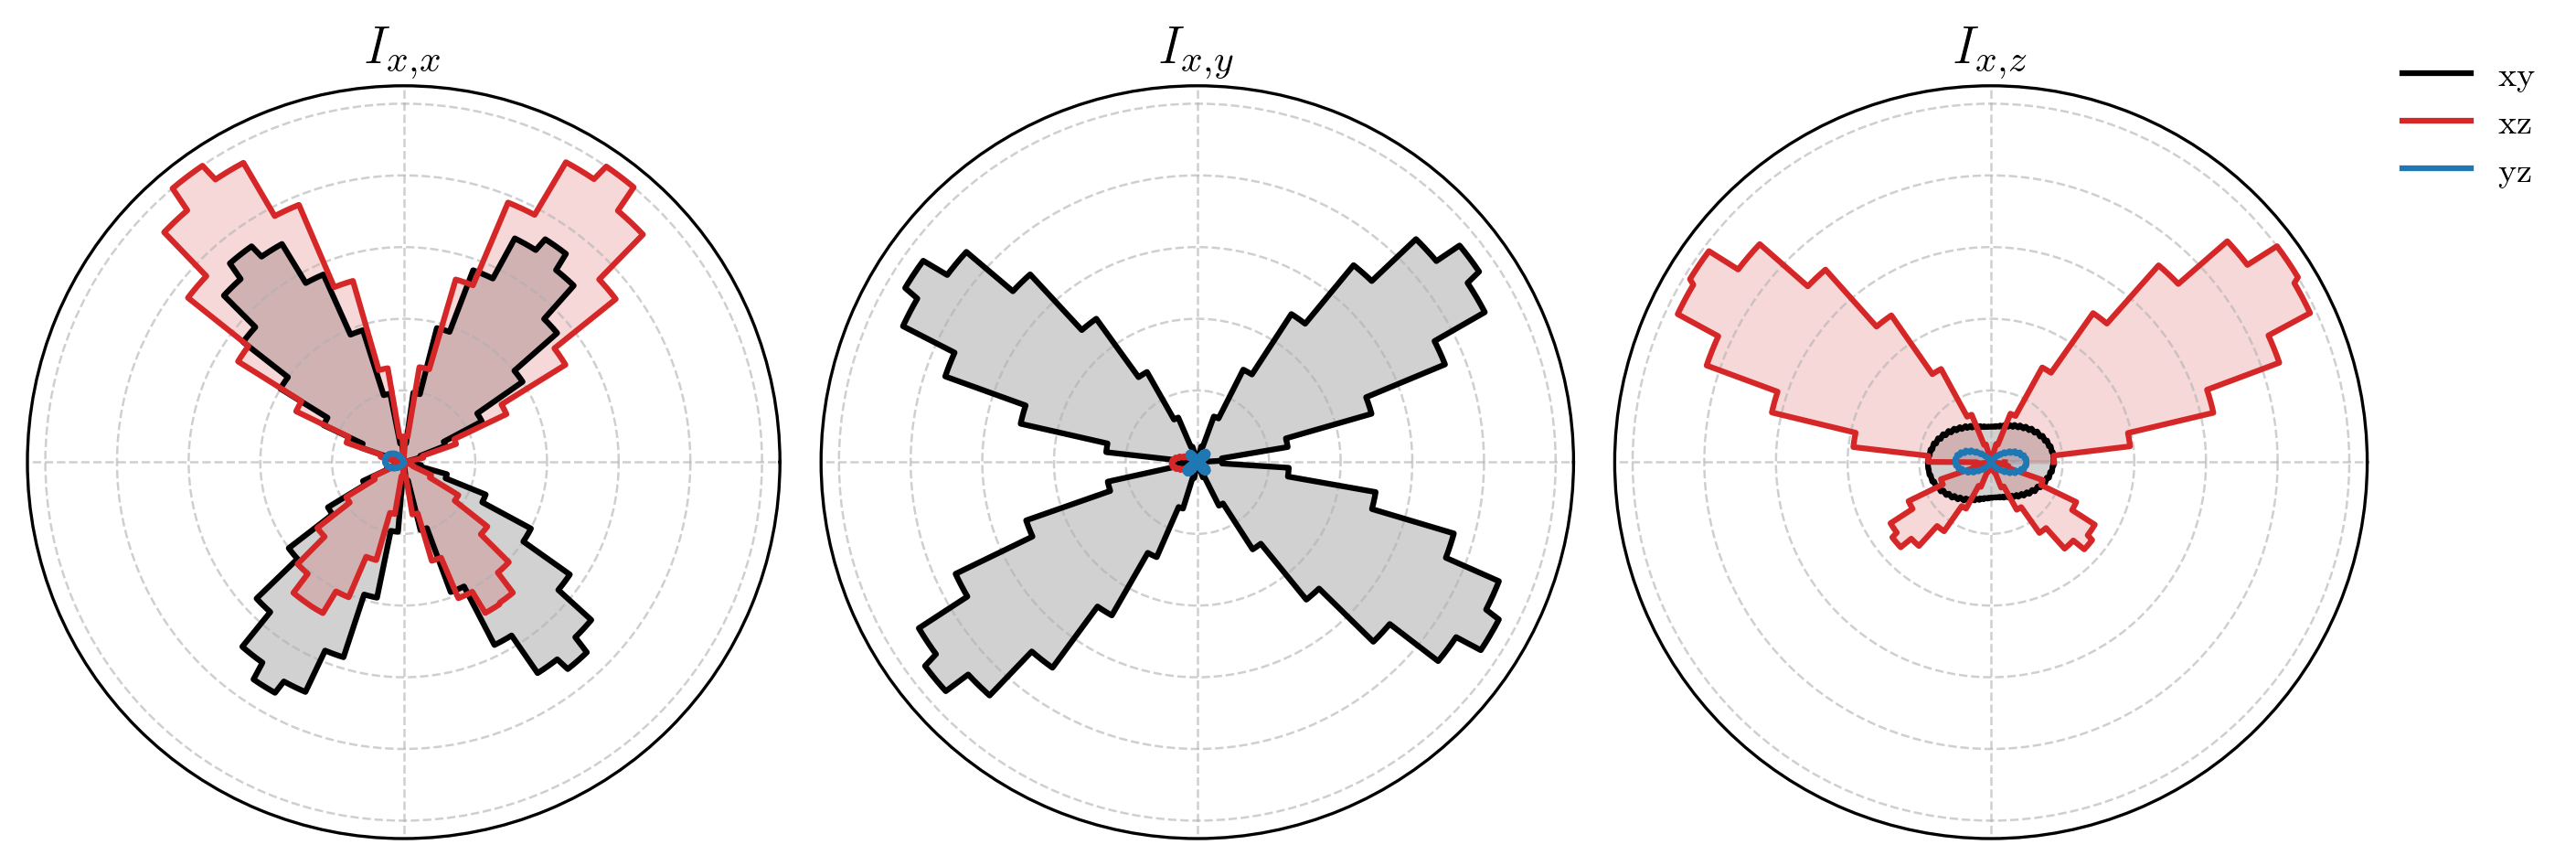

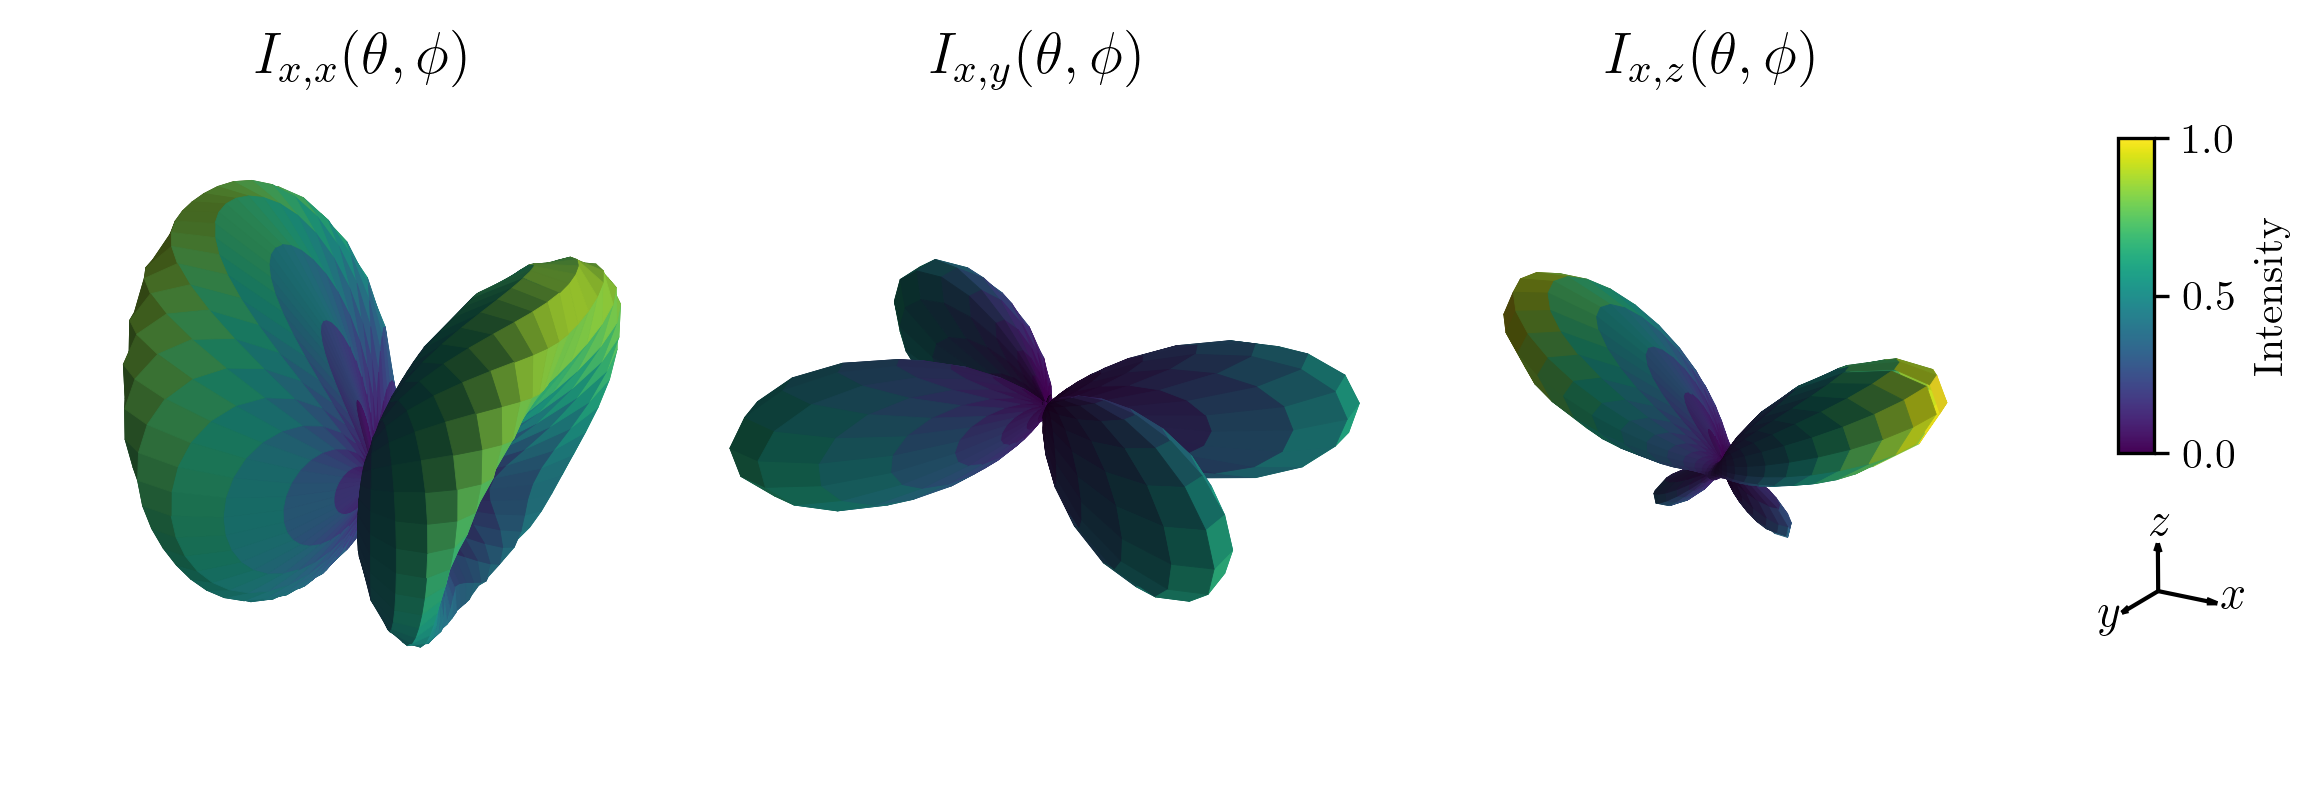

In [6]:
E_plus_x, E_minus_x, dE_x = com_scattered_farfield(geometry=geometry, step_nm=SPHERE_GEOMETRY_PARAMS["step_nm"], material=material, efield=hermite_efield, dyads=dyads, axis_index=0, 
                                                   disp_nm=disp_nm, Nteta=Ntheta, Nphi=Nphi, field_index=field_index, r=r)
I_x_total, I_x_Ex, I_x_Ey, I_x_Ez = info_patterns_from_scattered_field(dE=dE_x, delta_mu=disp_nm, wavelength_nm=wavelength_nm, Nteta=Ntheta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_x_Ex, I_x_Ey, I_x_Ez], labels=["x,x", "x,y", "x,z"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_x_2d", 
                     results_dir=results_dir)
plot3d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_x_Ex, I_x_Ey, I_x_Ez], labels=["x,x", "x,y", "x,z"], cmap=cm.viridis, 
                     scale_list=[0.4, 0.32, 0.36], savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_x_3d", results_dir=results_dir)

## COM displacement along y for the Hermite-Gauss field

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 94.8ms, inv.: 230.5ms, repropa.: 4840.2ms (1 field configs), tot: 5165.7ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 42.7ms, inv.: 230.5ms, repropa.: 4027.8ms (1 field configs), tot: 4301.2ms


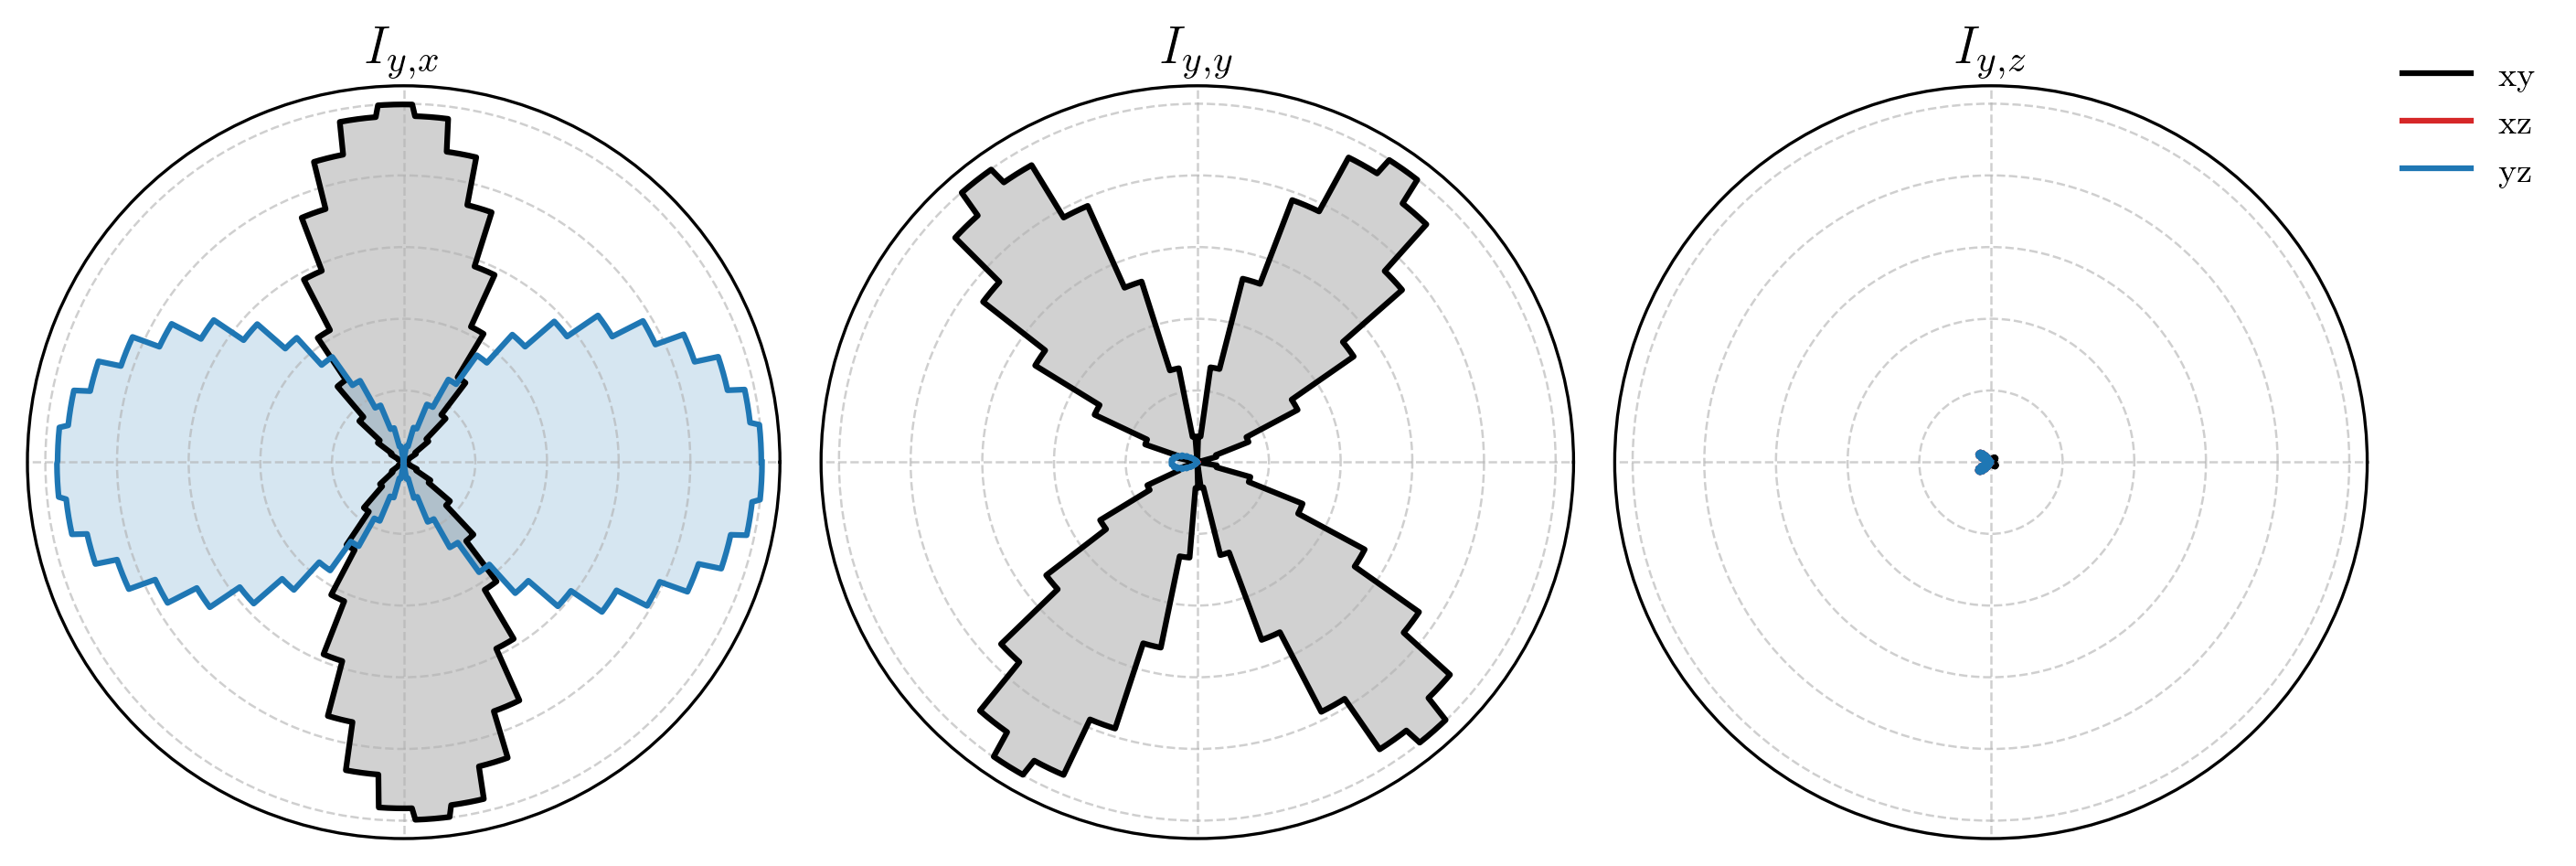

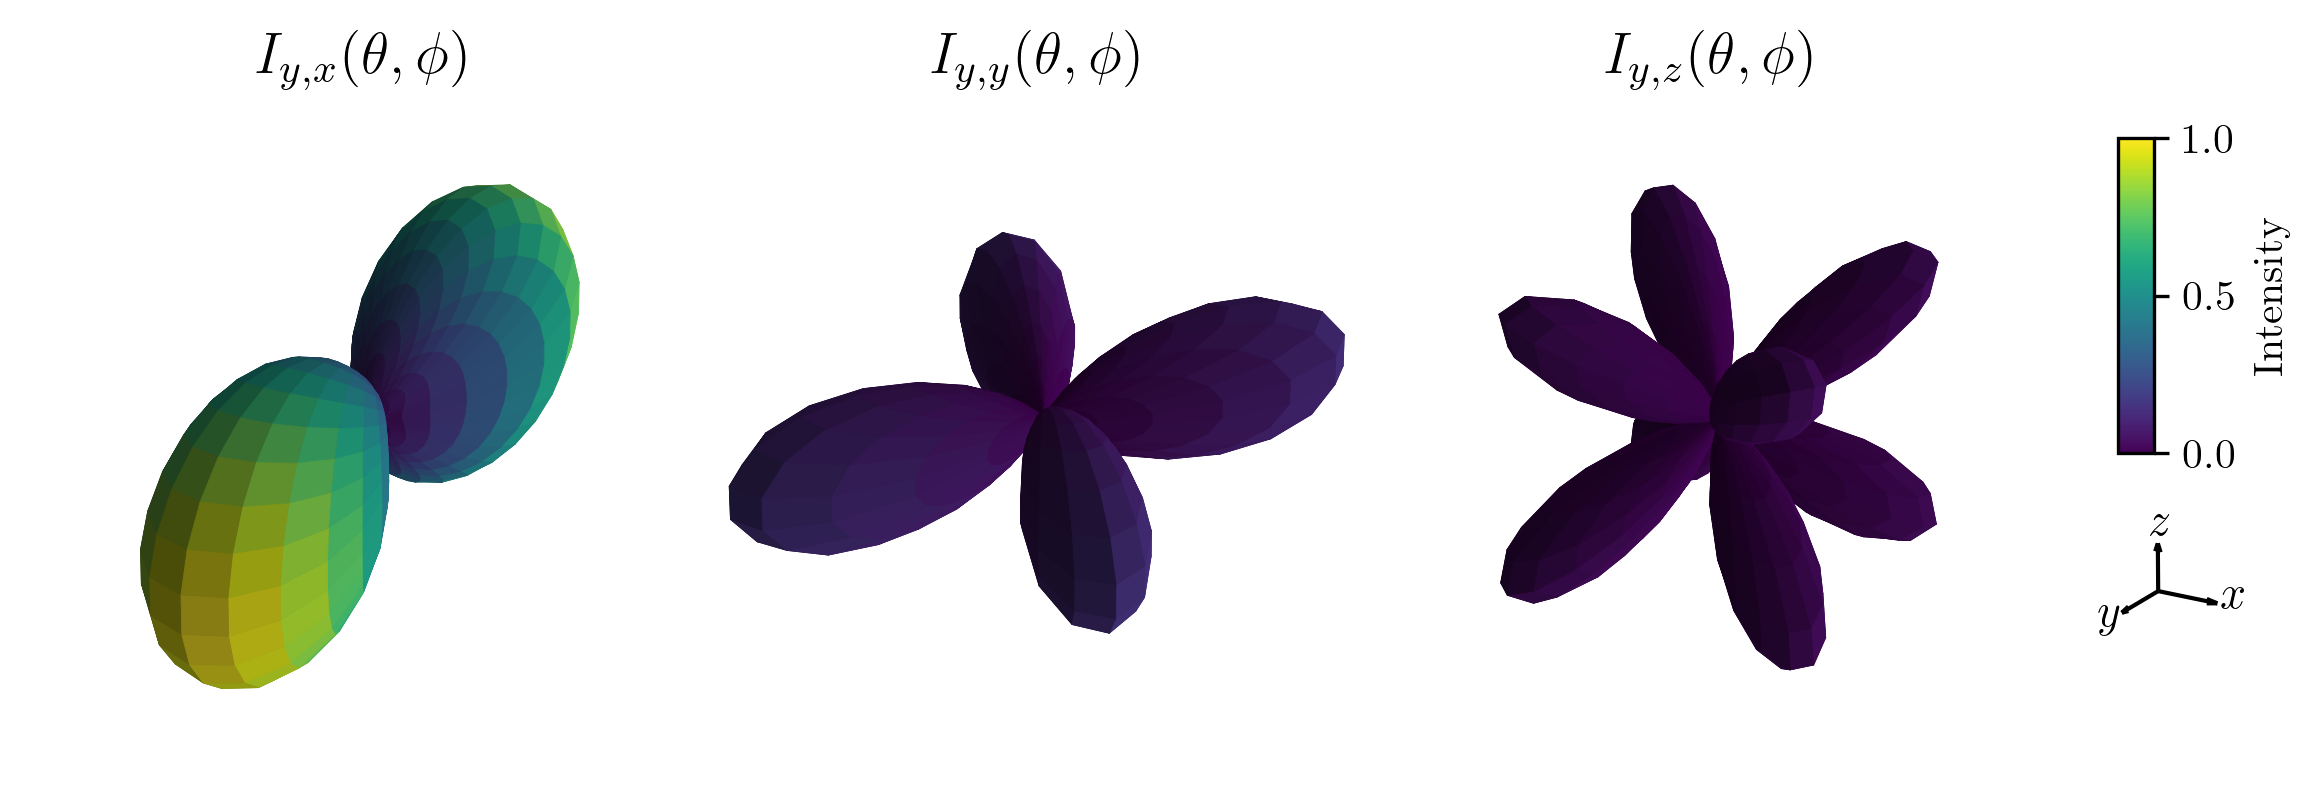

In [7]:
E_plus_y, E_minus_y, dE_y = com_scattered_farfield(geometry=geometry, step_nm=SPHERE_GEOMETRY_PARAMS["step_nm"], material=material, efield=hermite_efield, dyads=dyads, axis_index=1, 
                                                   disp_nm=disp_nm, Nteta=Ntheta, Nphi=Nphi, field_index=field_index, r=r)
I_y_total, I_y_Ex, I_y_Ey, I_y_Ez = info_patterns_from_scattered_field(dE=dE_y, delta_mu=disp_nm, wavelength_nm=wavelength_nm, Nteta=Ntheta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_y_Ex, I_y_Ey, I_y_Ez], labels=["y,x", "y,y", "y,z"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_y_2d", 
                     results_dir=results_dir)
plot3d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_y_Ex, I_y_Ey, I_y_Ez], labels=["y,x", "y,y", "y,z"], cmap=cm.viridis, 
                     scale_list=[0.22, 0.3, 0.48], savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_y_3d", results_dir=results_dir)

## COM displacement along z for the Hermite-Gauss field

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 63.9ms, inv.: 262.9ms, repropa.: 4666.8ms (1 field configs), tot: 4993.7ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 39.8ms, inv.: 229.5ms, repropa.: 5184.5ms (1 field configs), tot: 5454.0ms


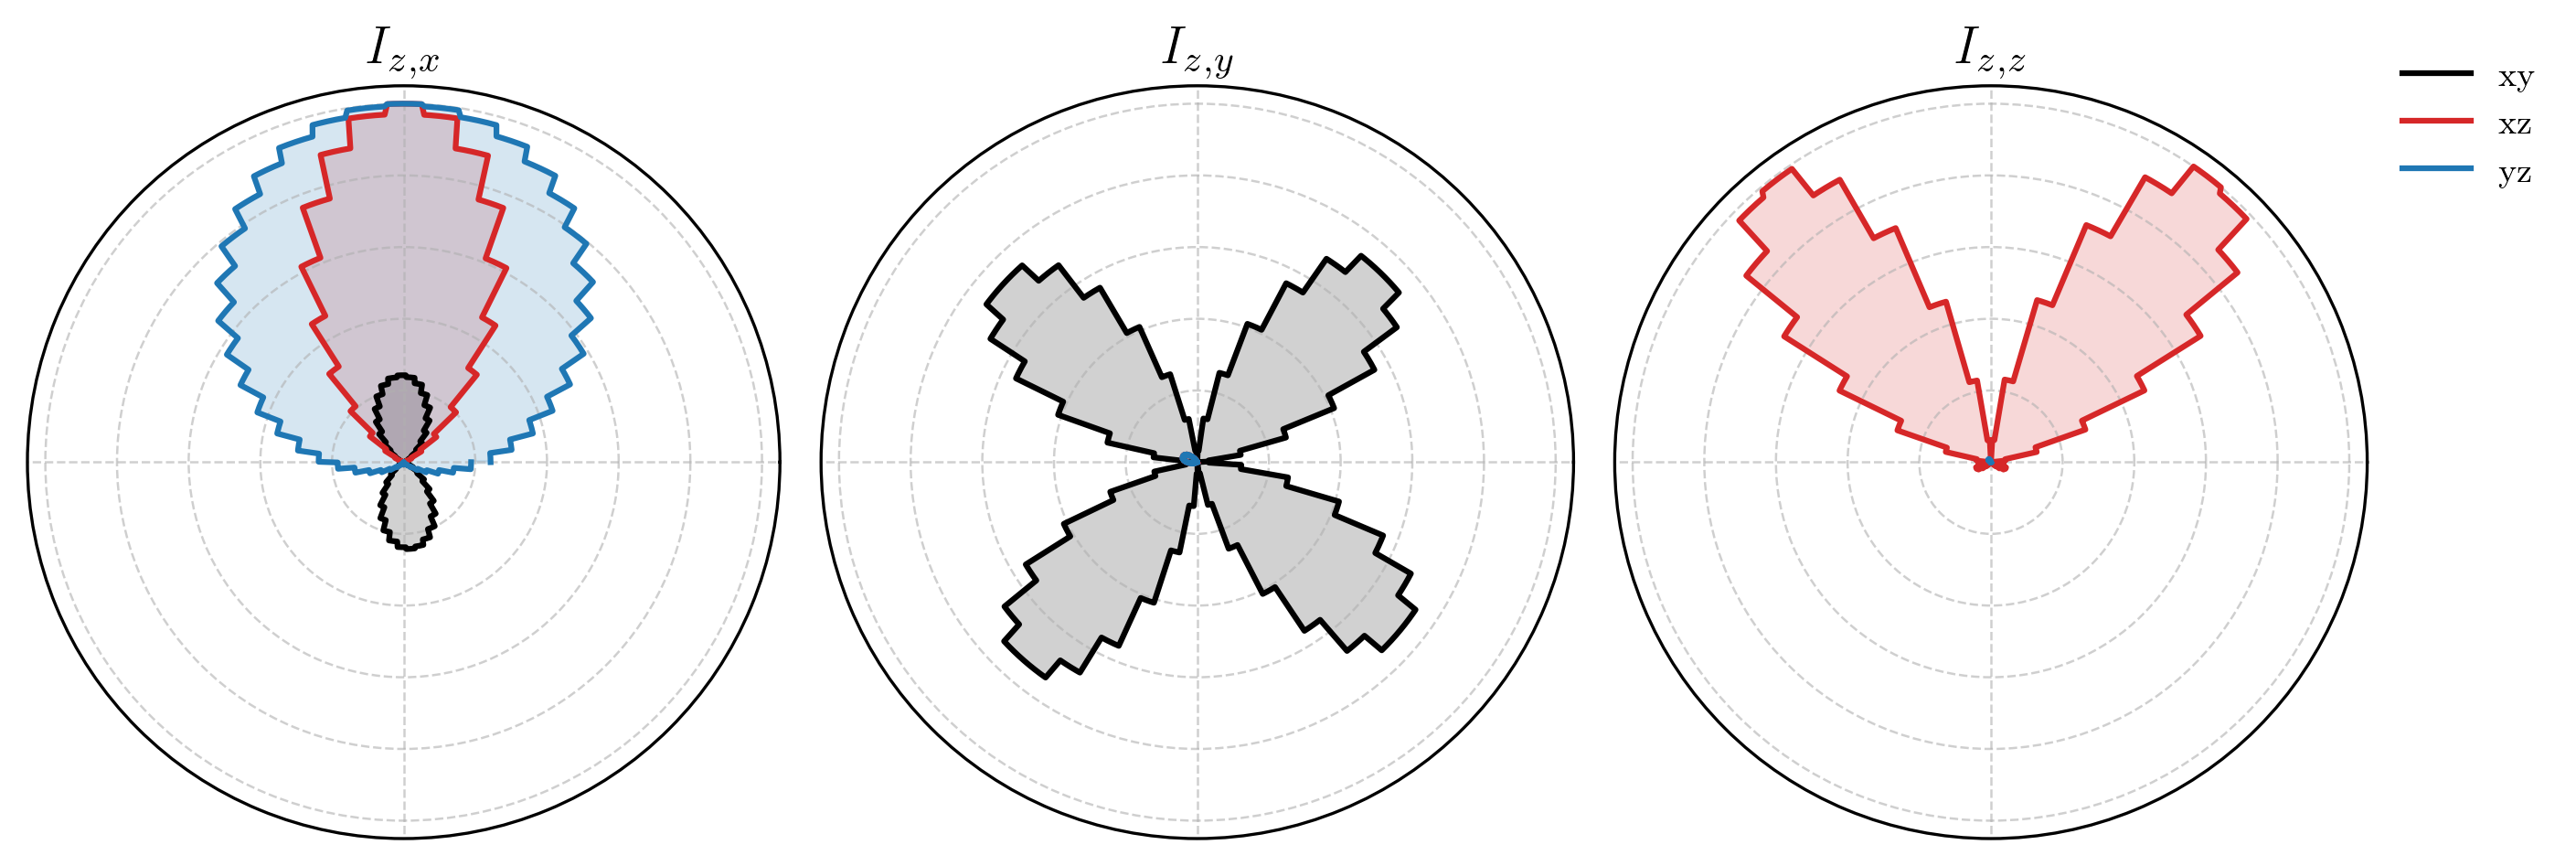

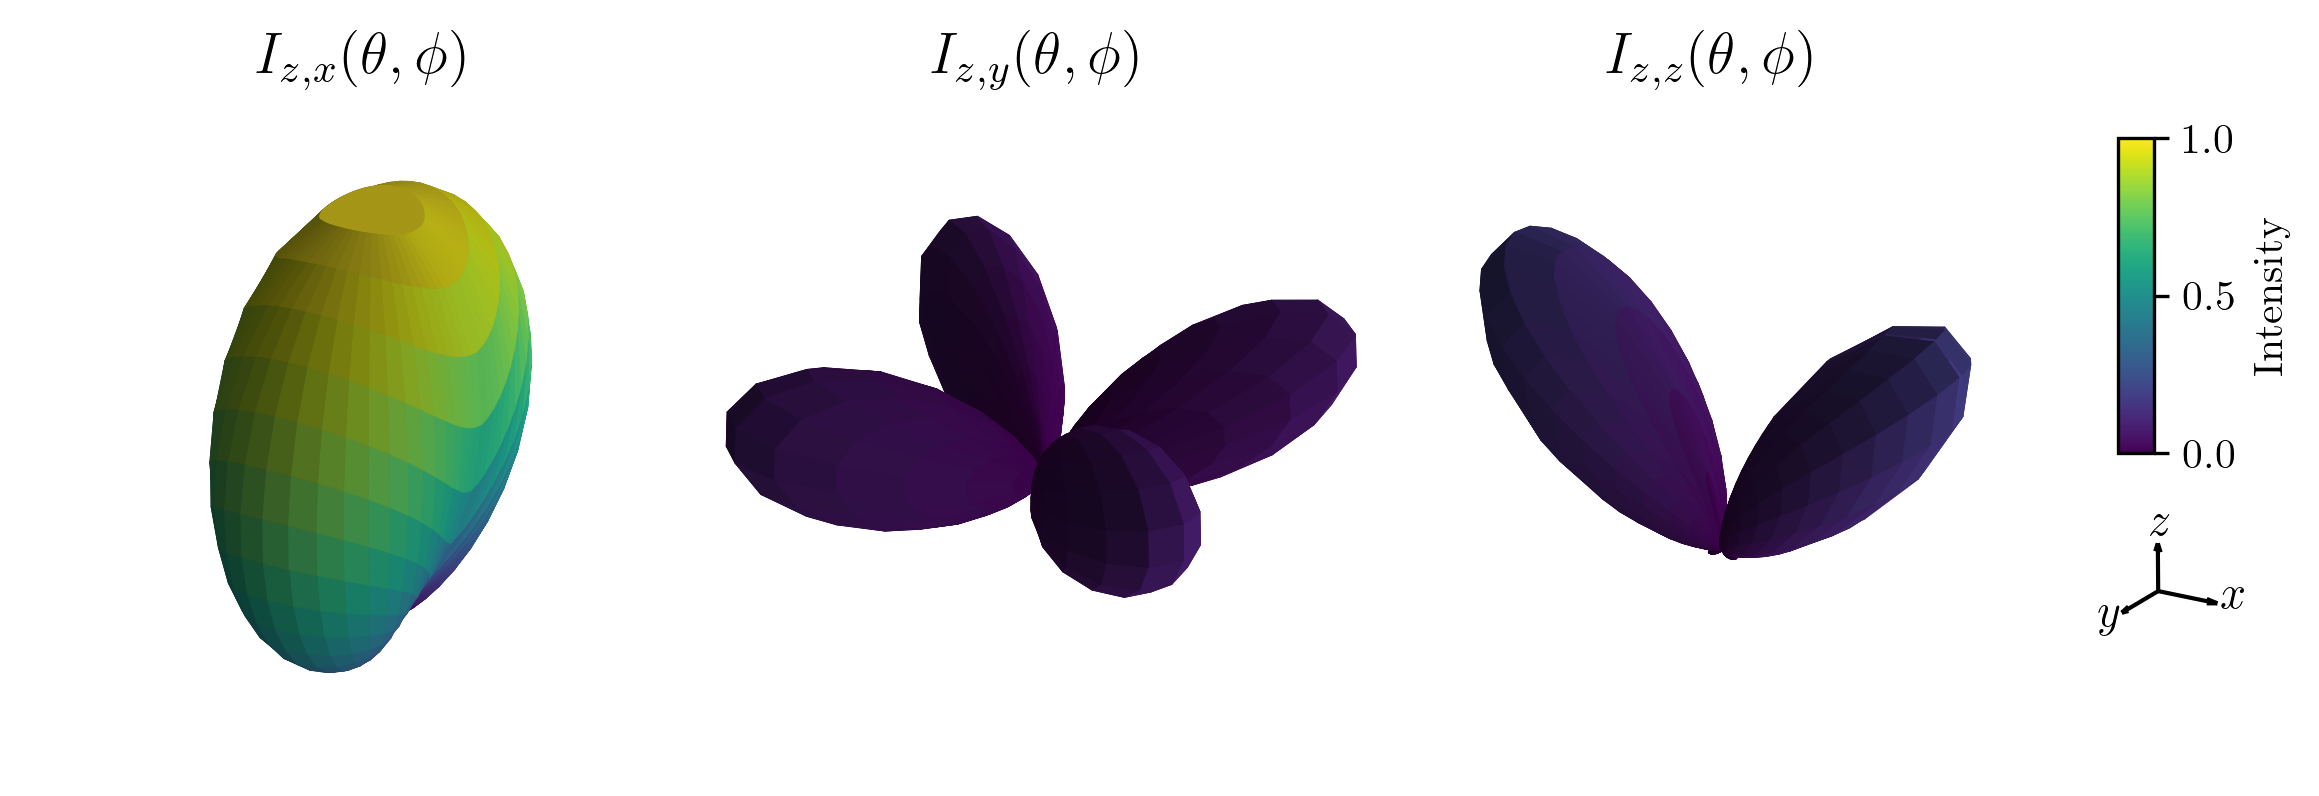

In [8]:
E_plus_z, E_minus_z, dE_z = com_scattered_farfield(geometry=geometry, step_nm=SPHERE_GEOMETRY_PARAMS["step_nm"], material=material, efield=hermite_efield, dyads=dyads, axis_index=2, 
                                                   disp_nm=disp_nm, Nteta=Ntheta, Nphi=Nphi, field_index=field_index, r=r)
I_z_total, I_z_Ex, I_z_Ey, I_z_Ez = info_patterns_from_scattered_field(dE=dE_z, delta_mu=disp_nm, wavelength_nm=wavelength_nm, Nteta=Ntheta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_z_Ex, I_z_Ey, I_z_Ez], labels=["z,x", "z,y", "z,z"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_z_2d", 
                     results_dir=results_dir)
plot3d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_z_Ex, I_z_Ey, I_z_Ez], labels=["z,x", "z,y", "z,z"], cmap=cm.viridis, 
                     scale_list=[0.36, 0.34, 0.33], savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_z_3d", results_dir=results_dir)

## Total COM information patterns for the Hermite-Gauss field

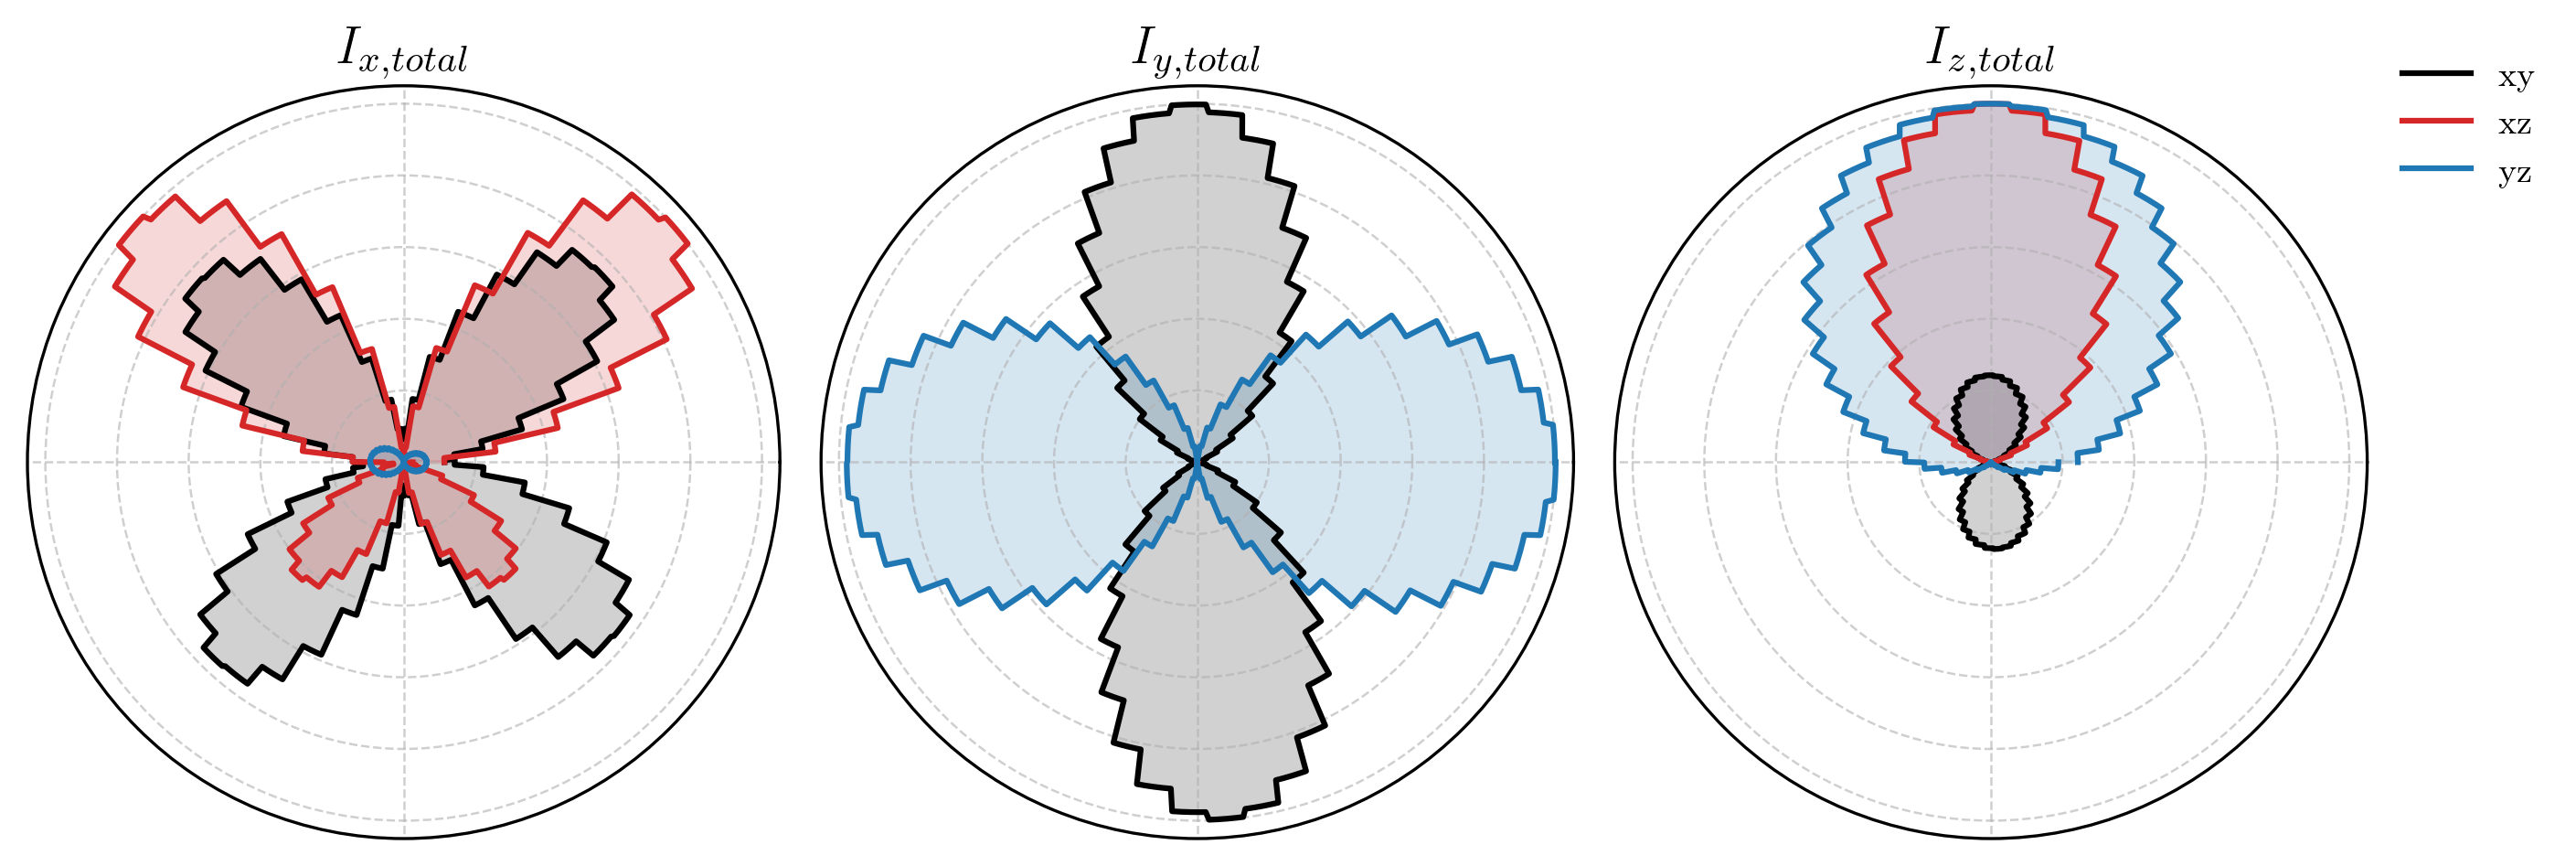

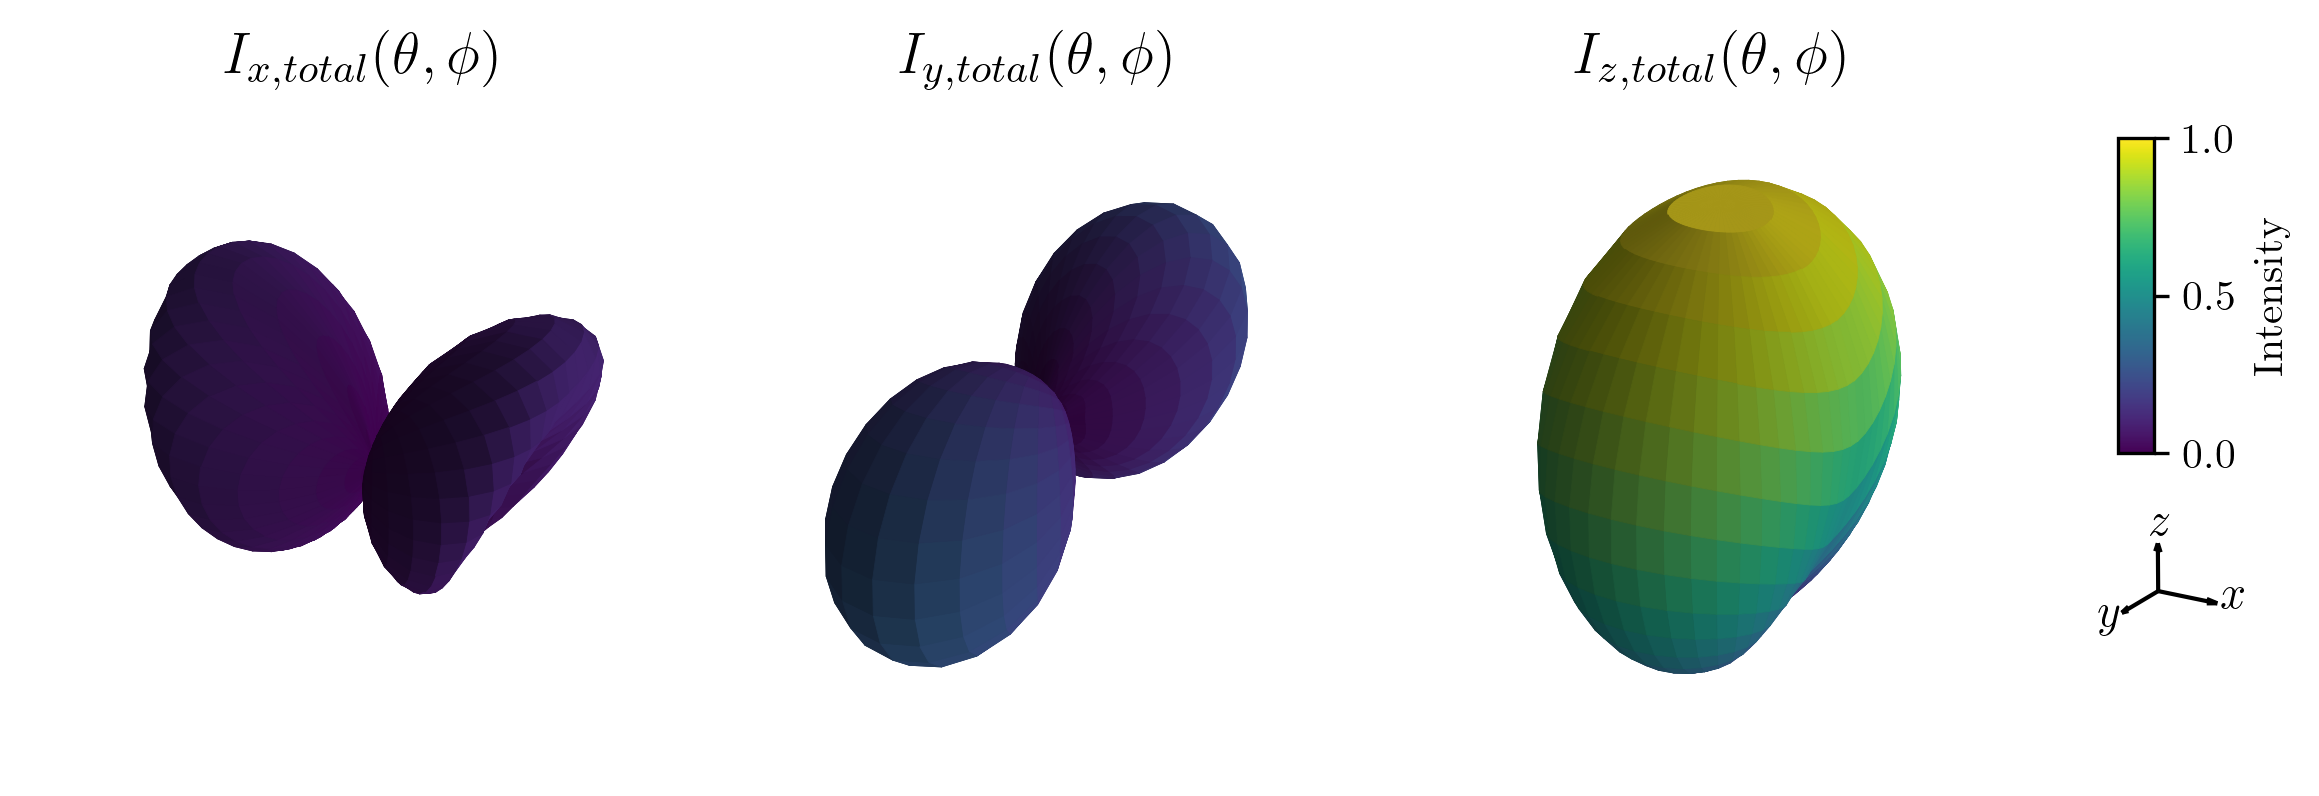

In [9]:
plot2d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_x_total, I_y_total, I_z_total], labels=["x,total", "y,total", "z,total"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_total_2d", 
                     results_dir=results_dir)
plot3d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_x_total, I_y_total, I_z_total], labels=["x,total", "y,total", "z,total"], cmap=cm.viridis, 
                     scale_list=[0.4, 0.24, 0.36], savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_total_3d", results_dir=results_dir)

## Radial doughnut incident field

Now, we build the `Radial_pol_doughnut` incident field using the same filling factor.

In [10]:
radial_params = DEFAULT_RADIAL_DOUGHNUT_FIELD_PARAMS.copy()
radial_params["w0"] = w0_from_filling_factor(gamma=gamma, NA=radial_params["NA"], f_mm=radial_params["f"])

print("Radial_pol_doughnut")
print("gamma =", gamma)
print("NA =", radial_params["NA"])
print("f =", radial_params["f"], "mm")
print("w0 =", radial_params["w0"], "mm")

radial_efield = incident_field(**radial_params)

Radial_pol_doughnut
gamma = 1.0
NA = 0.8
f = 3.0 mm
w0 = 2.4000000000000004 mm


## COM displacement along x for the radial doughnut field

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 63.6ms, inv.: 250.6ms, repropa.: 4154.7ms (1 field configs), tot: 4469.0ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 40.8ms, inv.: 229.8ms, repropa.: 5273.0ms (1 field configs), tot: 5543.8ms


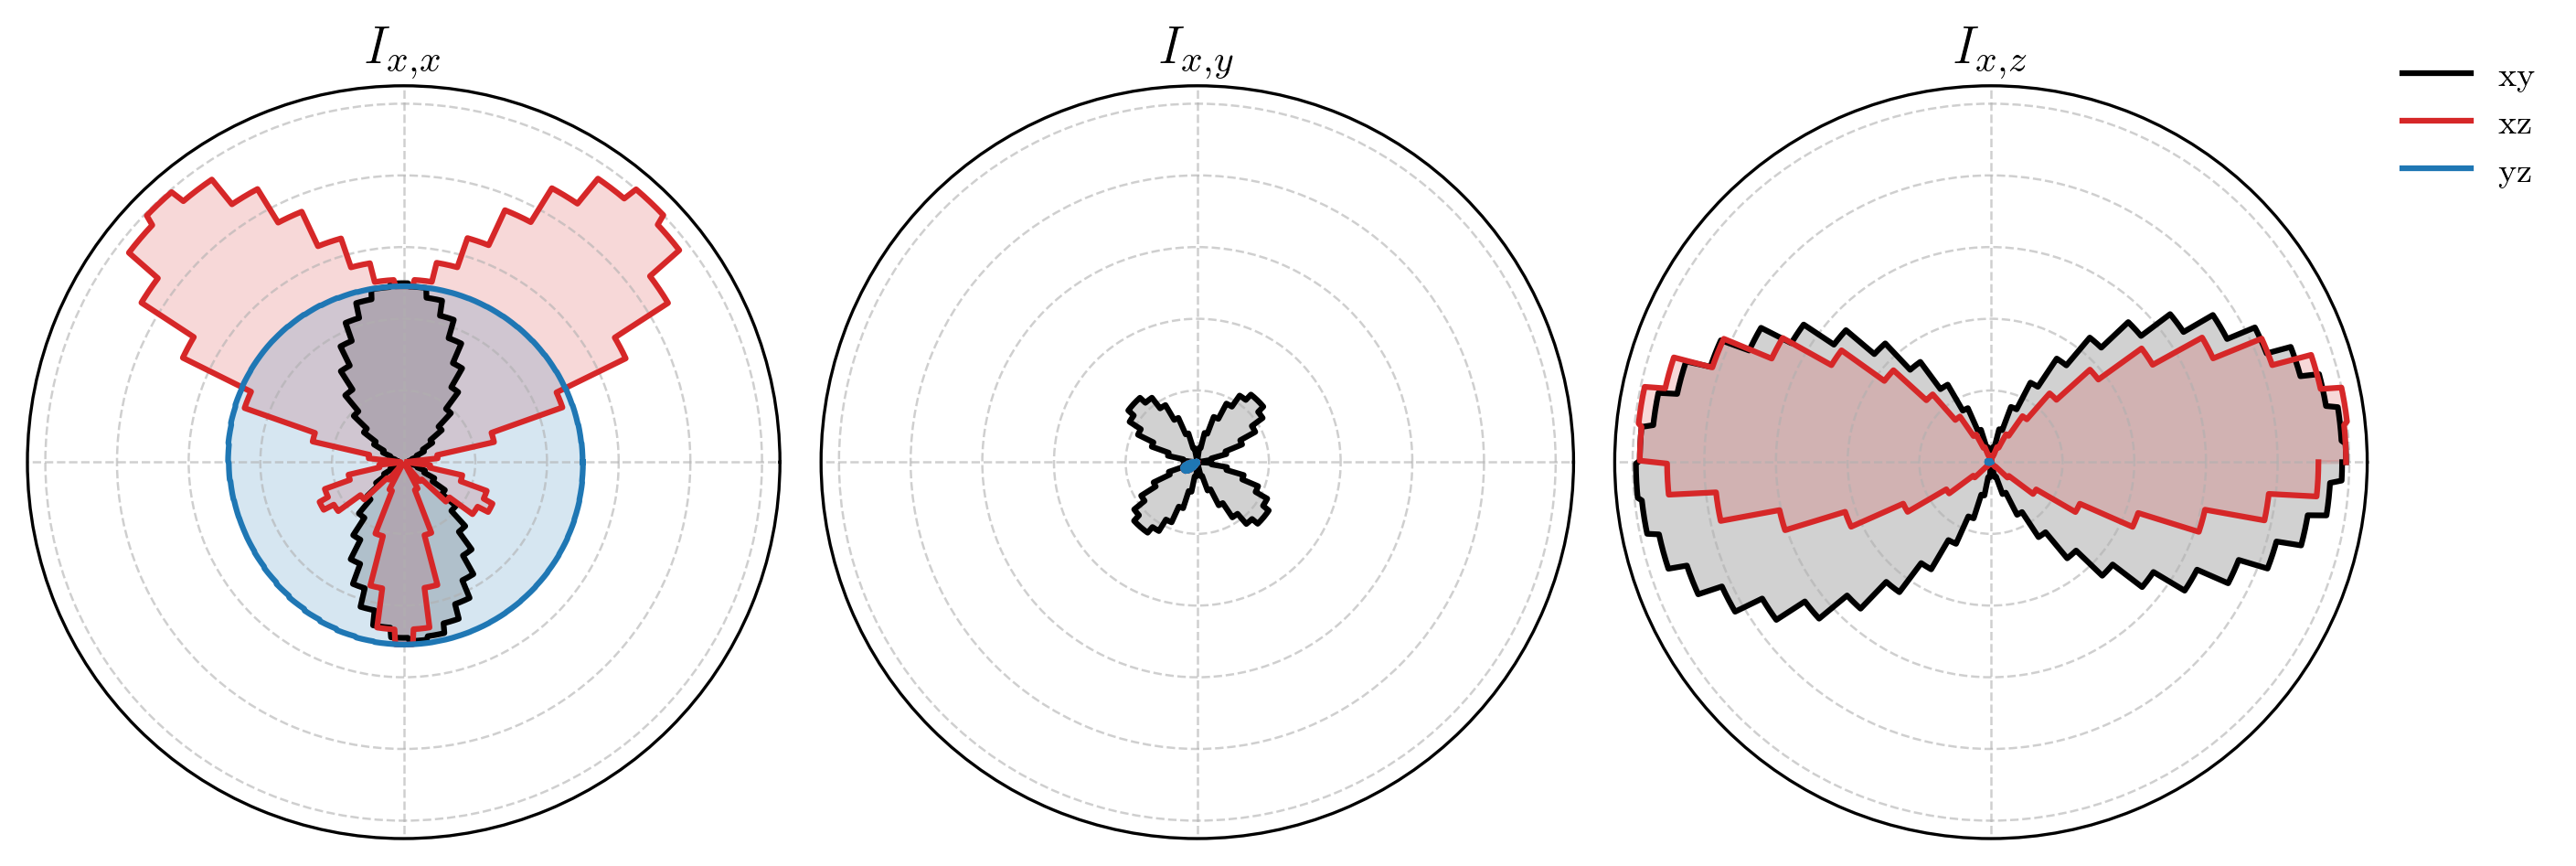

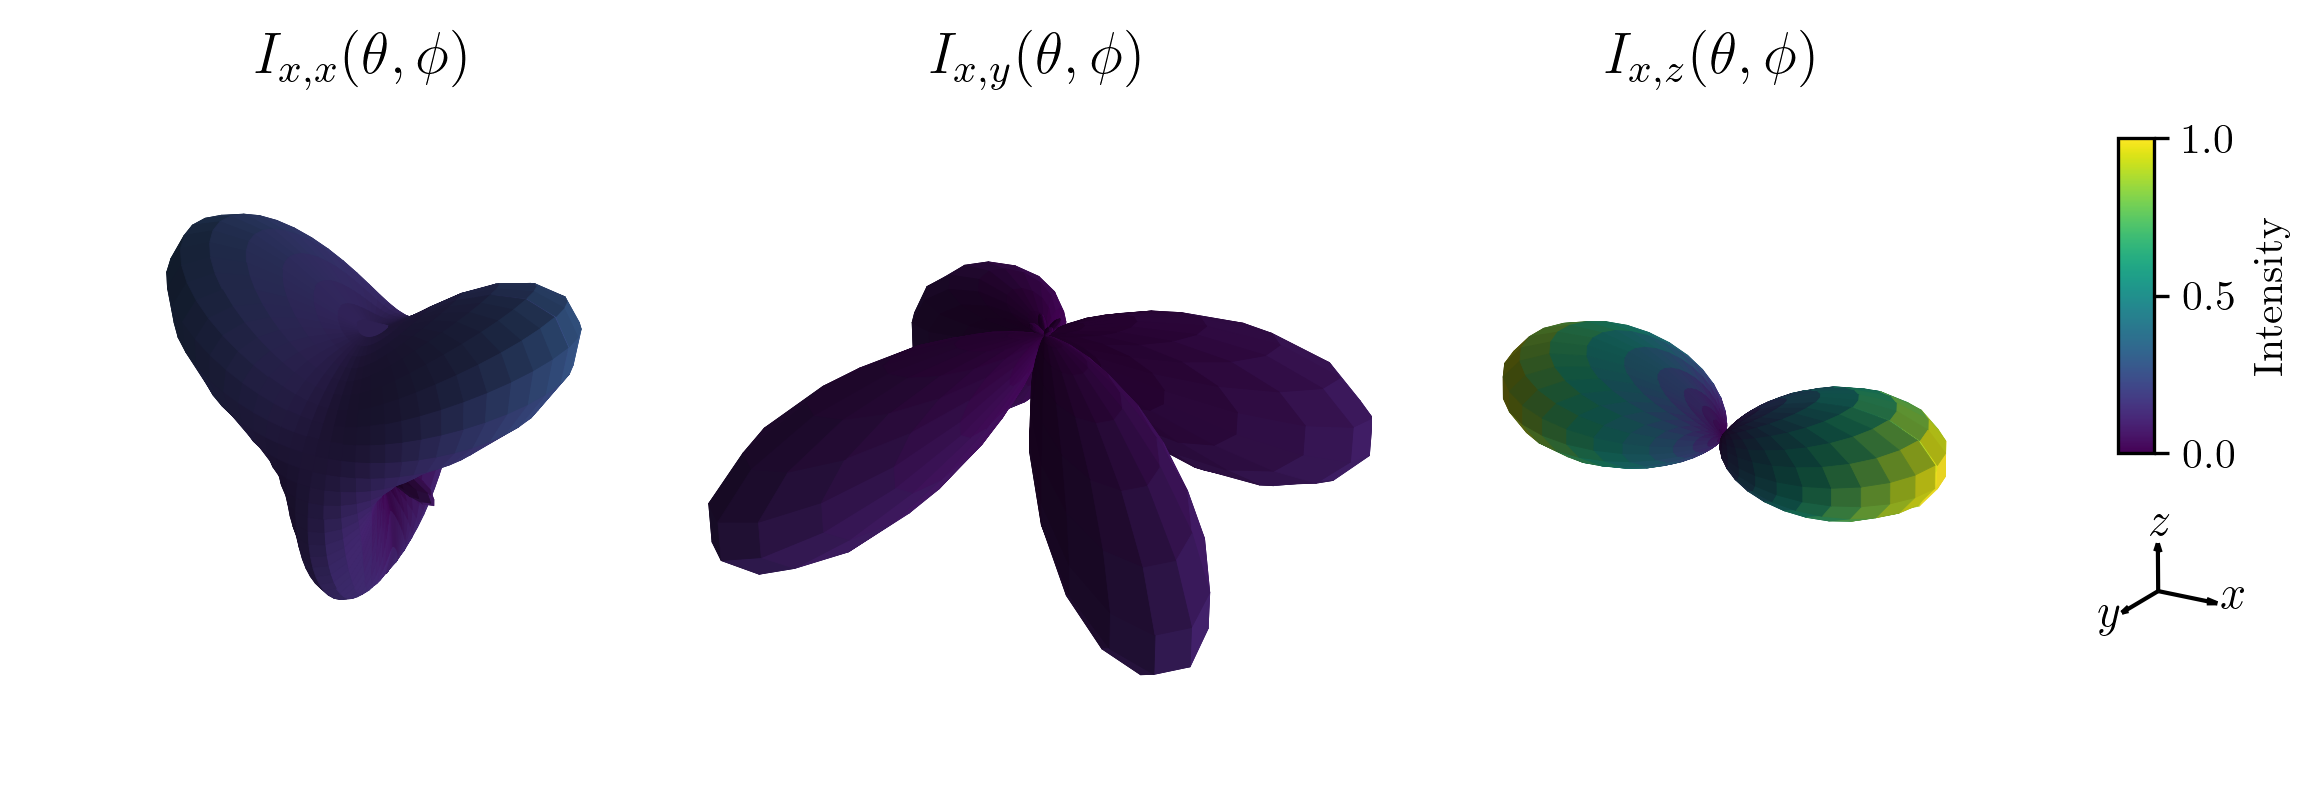

In [11]:
E_plus_x, E_minus_x, dE_x = com_scattered_farfield(geometry=geometry, step_nm=SPHERE_GEOMETRY_PARAMS["step_nm"], material=material, efield=radial_efield, dyads=dyads, axis_index=0, 
                                                   disp_nm=disp_nm, Nteta=Ntheta, Nphi=Nphi, field_index=field_index, r=r)
I_x_total, I_x_Ex, I_x_Ey, I_x_Ez = info_patterns_from_scattered_field(dE=dE_x, delta_mu=disp_nm, wavelength_nm=wavelength_nm, Nteta=Ntheta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_x_Ex, I_x_Ey, I_x_Ez], labels=["x,x", "x,y", "x,z"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_x_2d", 
                     results_dir=results_dir)
plot3d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_x_Ex, I_x_Ey, I_x_Ez], labels=["x,x", "x,y", "x,z"], cmap=cm.viridis, 
                     scale_list=[0.4, 0.32, 0.36], savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_x_3d", results_dir=results_dir)

## COM displacement along y for the radial doughnut field

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 69.2ms, inv.: 252.3ms, repropa.: 4607.8ms (1 field configs), tot: 4929.4ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 42.9ms, inv.: 241.1ms, repropa.: 4300.3ms (1 field configs), tot: 4584.4ms


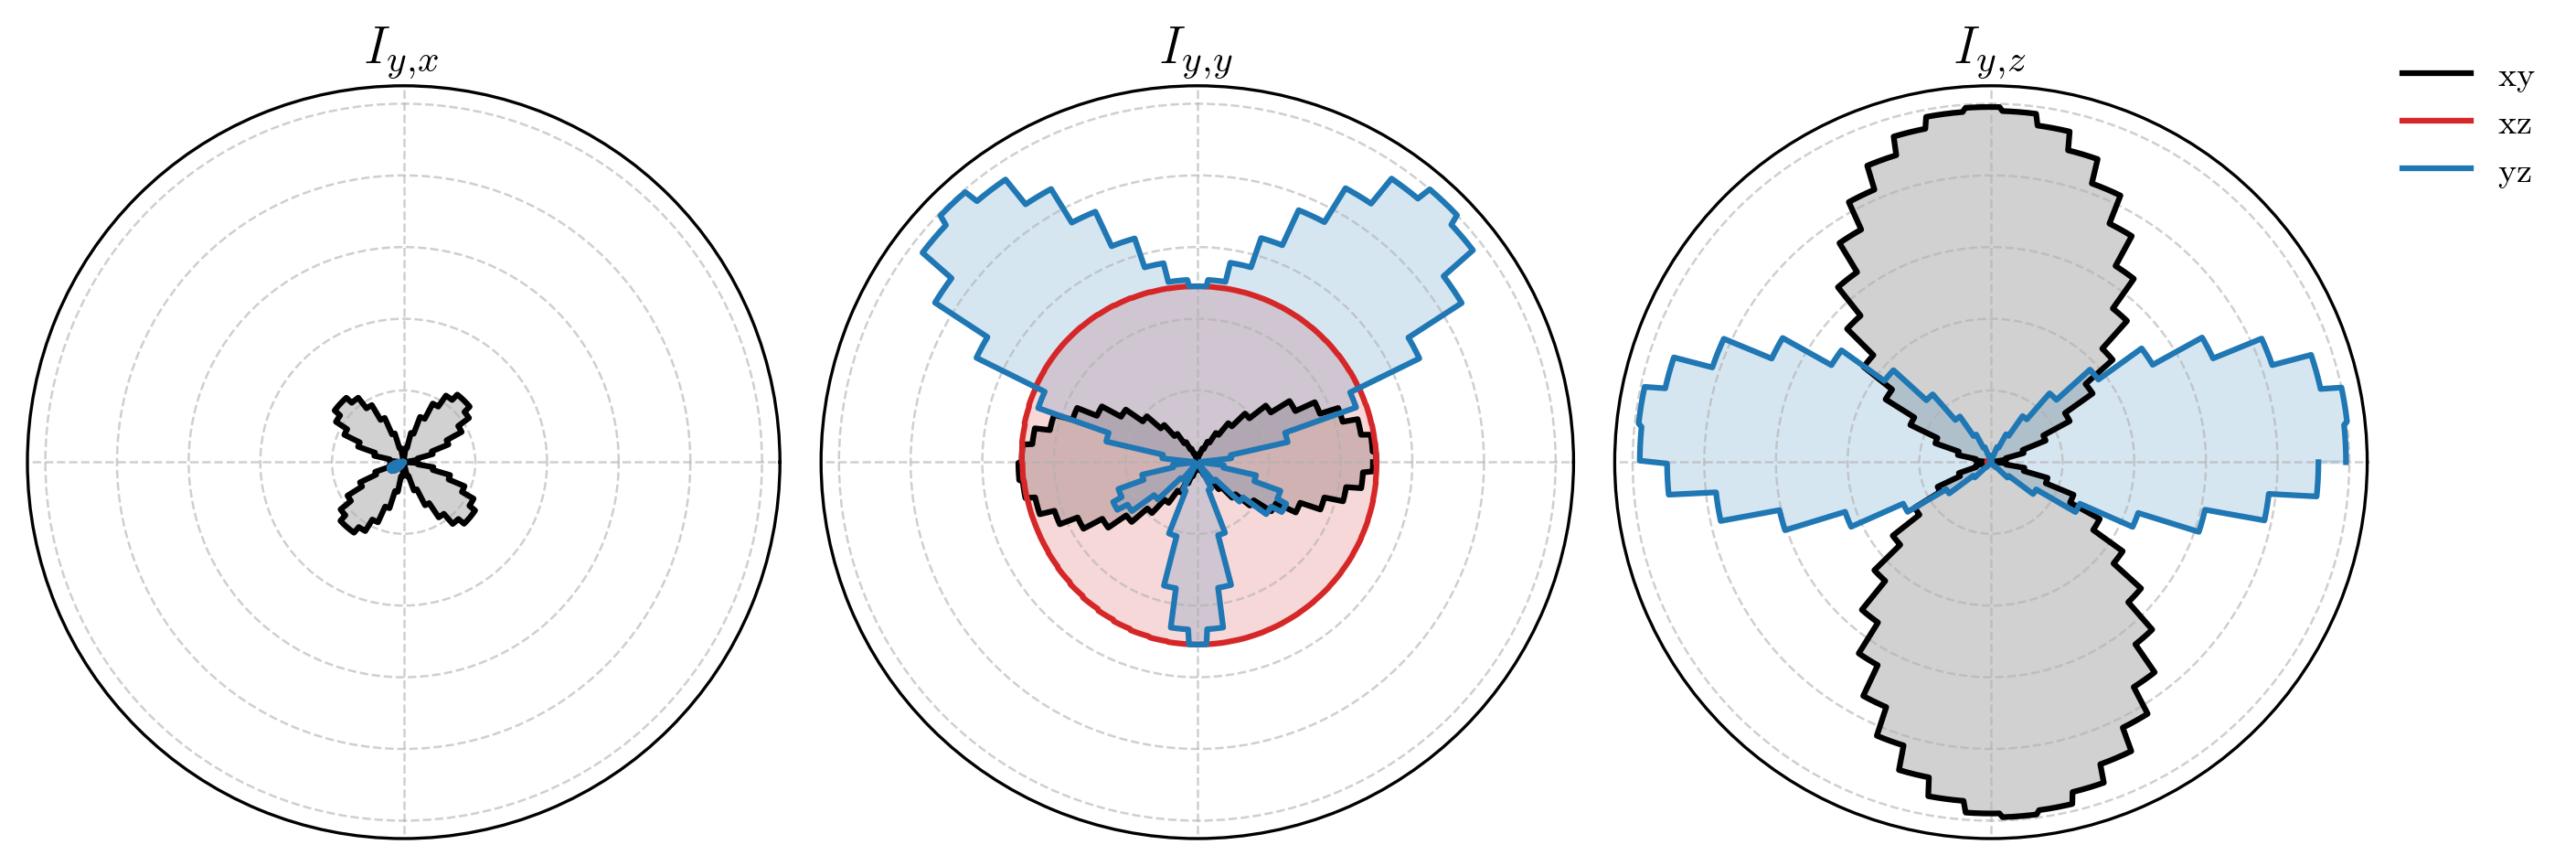

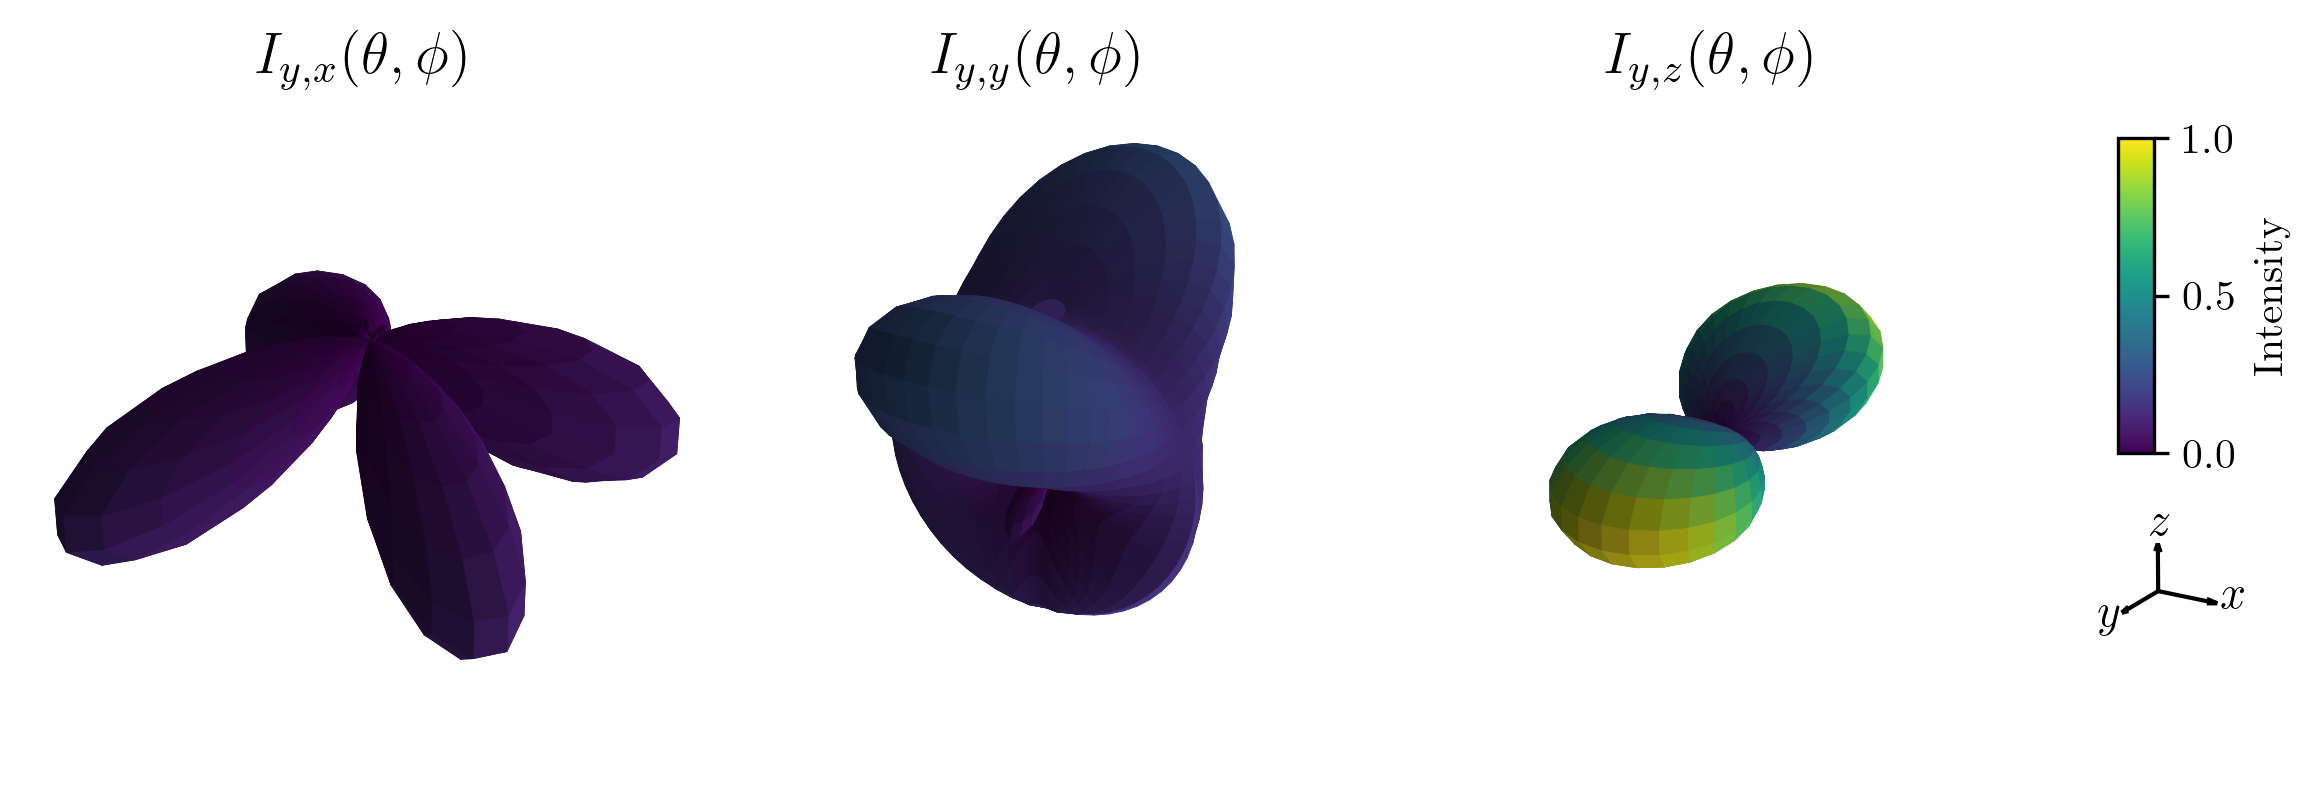

In [12]:
E_plus_y, E_minus_y, dE_y = com_scattered_farfield(geometry=geometry, step_nm=SPHERE_GEOMETRY_PARAMS["step_nm"], material=material, efield=radial_efield, dyads=dyads, axis_index=1, 
                                                   disp_nm=disp_nm, Nteta=Ntheta, Nphi=Nphi, field_index=field_index, r=r)
I_y_total, I_y_Ex, I_y_Ey, I_y_Ez = info_patterns_from_scattered_field(dE=dE_y, delta_mu=disp_nm, wavelength_nm=wavelength_nm, Nteta=Ntheta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_y_Ex, I_y_Ey, I_y_Ez], labels=["y,x", "y,y", "y,z"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_y_2d", 
                     results_dir=results_dir)
plot3d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_y_Ex, I_y_Ey, I_y_Ez], labels=["y,x", "y,y", "y,z"], cmap=cm.viridis, 
                     scale_list=[0.34, 0.34, 0.34], savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_y_3d", results_dir=results_dir)

## COM displacement along z for the radial doughnut field

structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 56.9ms, inv.: 250.5ms, repropa.: 4282.4ms (1 field configs), tot: 4589.9ms
structure initialization - automatic mesh detection: hex
structure initialization - consistency check: 853/853 dipoles valid
timing for wl=1550.00nm - setup: EE 43.7ms, inv.: 229.2ms, repropa.: 4282.1ms (1 field configs), tot: 4555.2ms


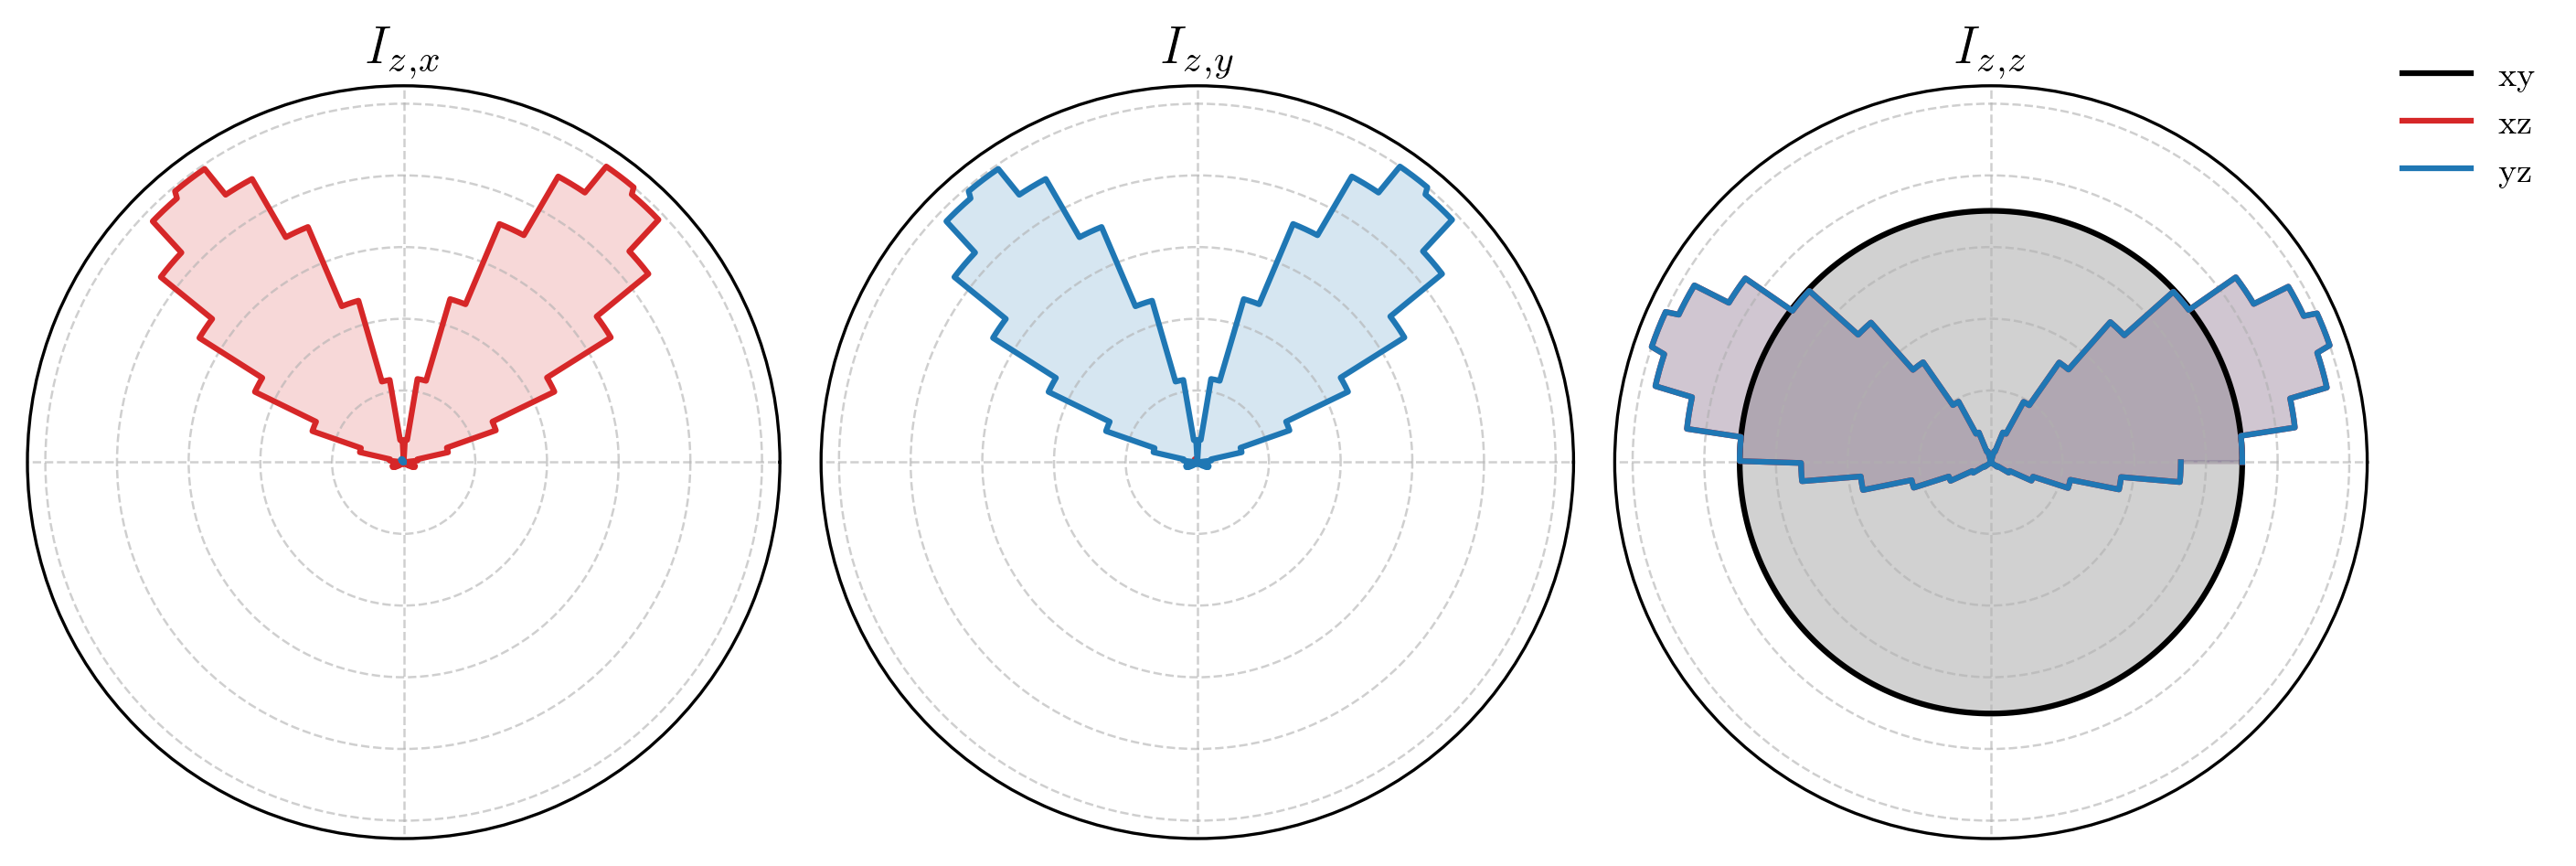

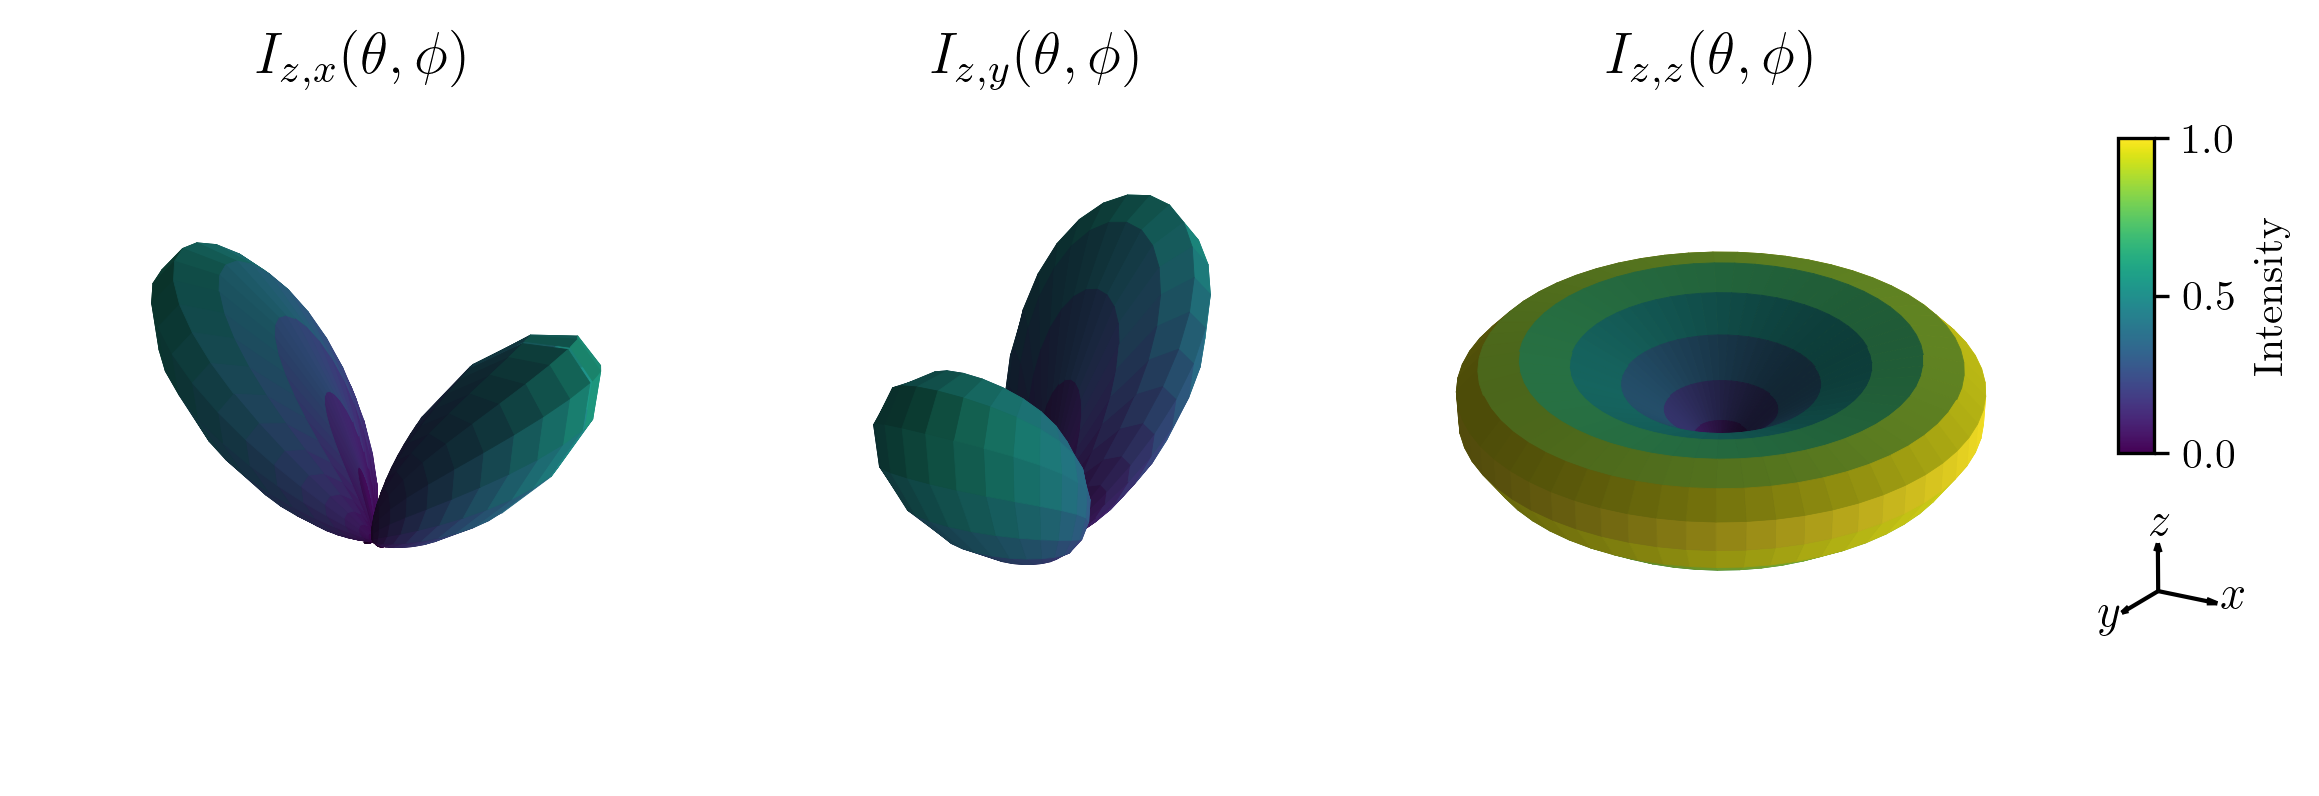

In [13]:
E_plus_z, E_minus_z, dE_z = com_scattered_farfield(geometry=geometry, step_nm=SPHERE_GEOMETRY_PARAMS["step_nm"], material=material, efield=radial_efield, dyads=dyads, axis_index=2, 
                                                   disp_nm=disp_nm, Nteta=Ntheta, Nphi=Nphi, field_index=field_index, r=r)
I_z_total, I_z_Ex, I_z_Ey, I_z_Ez = info_patterns_from_scattered_field(dE=dE_z, delta_mu=disp_nm, wavelength_nm=wavelength_nm, Nteta=Ntheta, Nphi=Nphi)
plot2d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_z_Ex, I_z_Ey, I_z_Ez], labels=["z,x", "z,y", "z,z"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_z_2d", 
                     results_dir=results_dir)
plot3d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_z_Ex, I_z_Ey, I_z_Ez], labels=["z,x", "z,y", "z,z"], cmap=cm.viridis, 
                     scale_list=[0.36, 0.34, 0.33], savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_z_3d", results_dir=results_dir)

## Total COM information patterns for the radial doughnut field

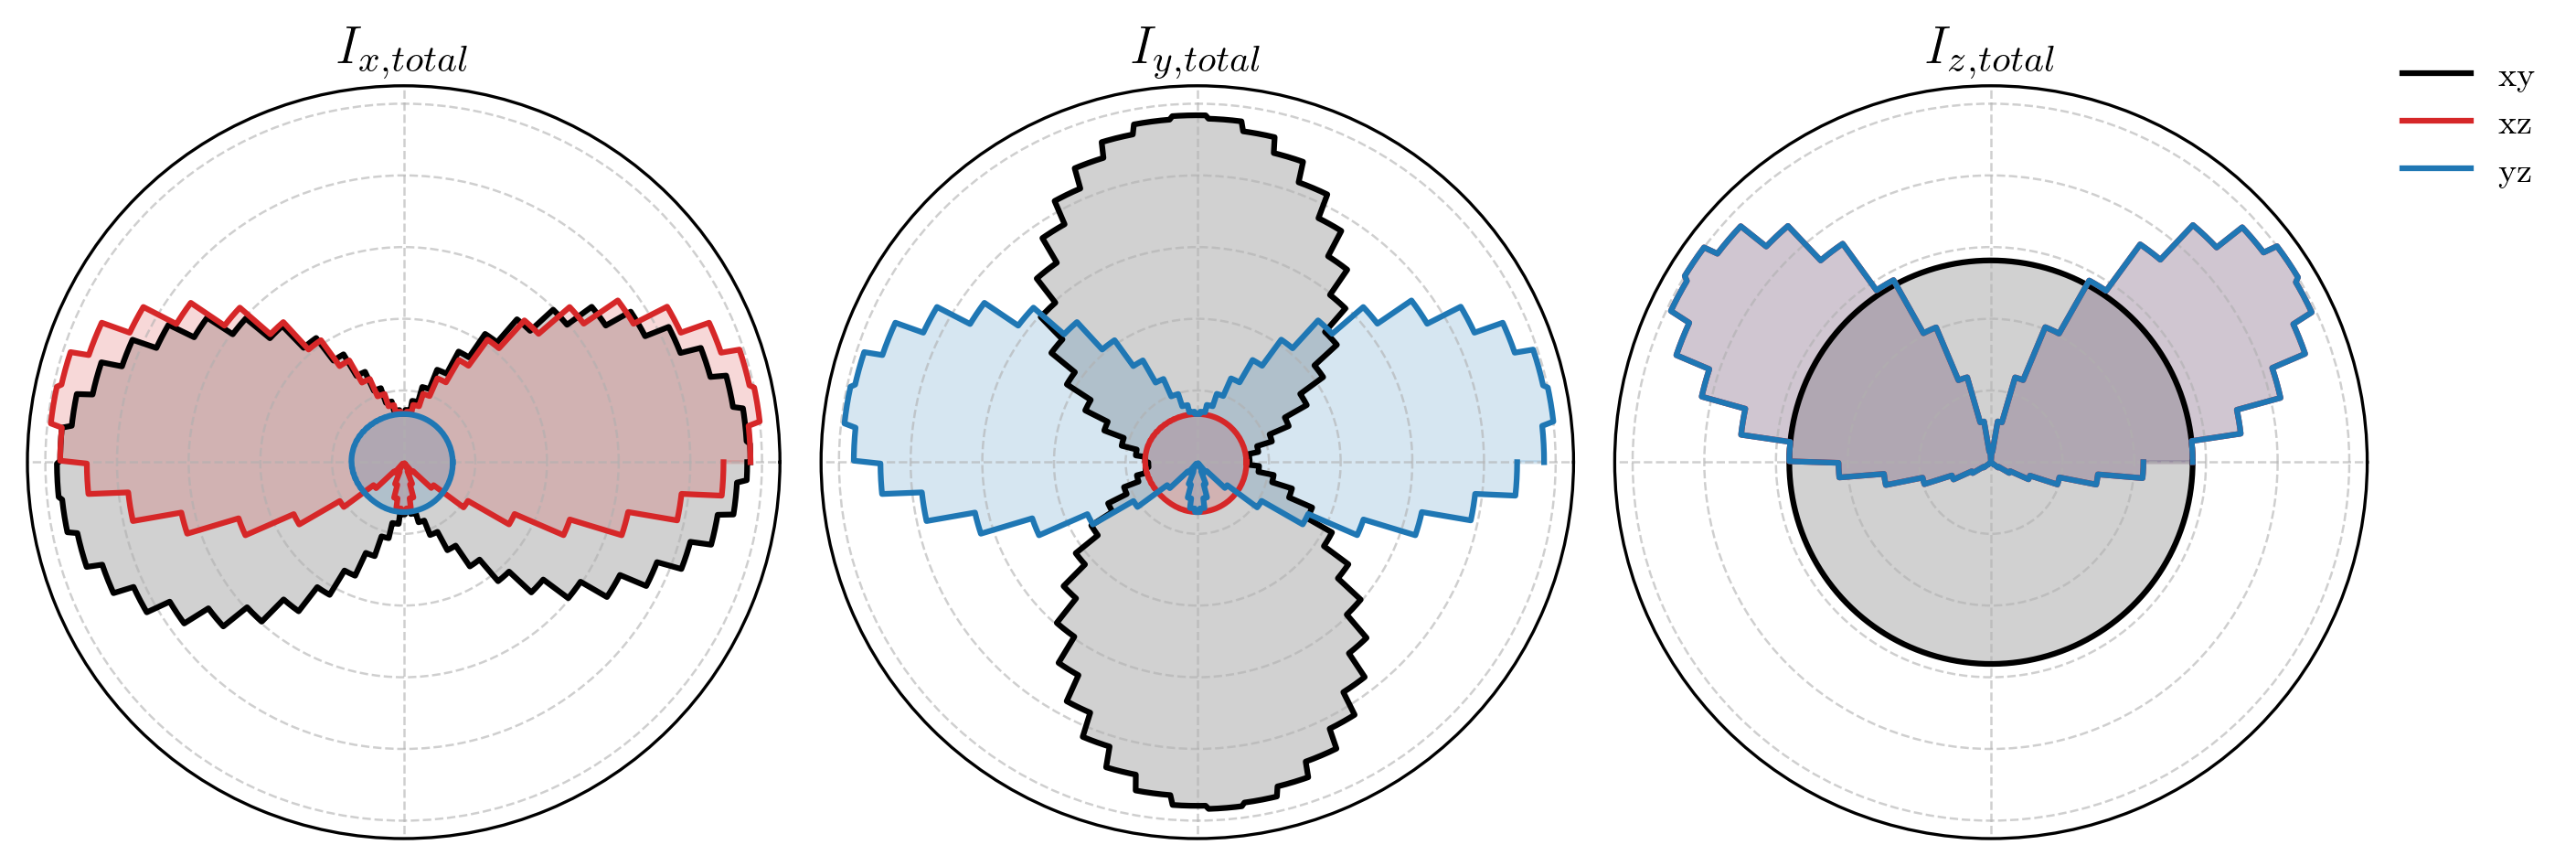

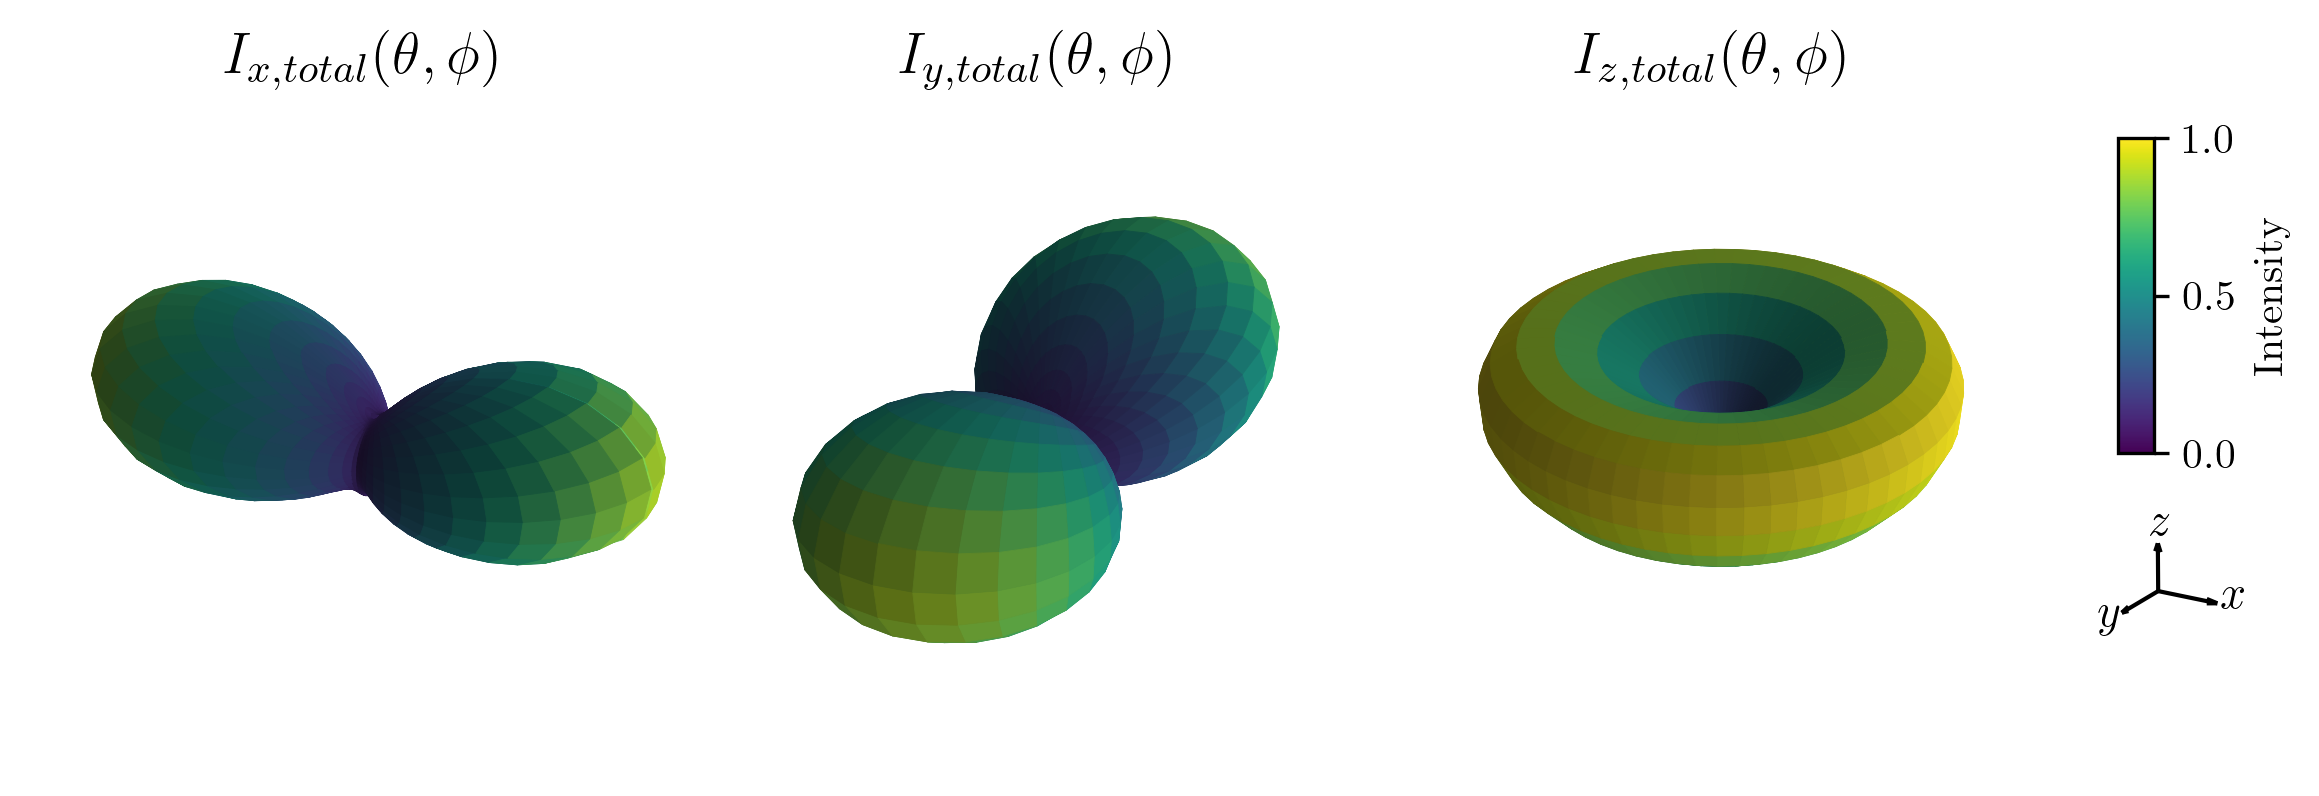

In [14]:
plot2d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_x_total, I_y_total, I_z_total], labels=["x,total", "y,total", "z,total"], planes=DEFAULT_2D_PLANES, 
                     normalize=DEFAULT_2D_NORMALIZE, fill=DEFAULT_2D_FILL, figsize=None, savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_total_2d", 
                     results_dir=results_dir)
plot3d_info_patterns(Nteta=Ntheta, Nphi=Nphi, info_patterns=[I_x_total, I_y_total, I_z_total], labels=["x,total", "y,total", "z,total"], cmap=cm.viridis, 
                     scale_list=[0.28, 0.24, 0.36], savefig=False, save_type=DEFAULT_SAVE_TYPE, filename="richards_wolf_info_patterns_total_3d", results_dir=results_dir)